In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import networkExpansionPy.folds as nf
import networkExpansionPy.lib as ne
import glob
import csv
import json
import ast
from scipy.stats import mannwhitneyu
from scipy.stats import spearmanr
from decimal import Decimal
import requests
import random

from sklearn.decomposition import PCA

/Users/tseamuscorlett/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/tseamuscorlett/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


In [2]:
def todata(dict1, dict2, val_type = 'MEAN'):
    valid_keys = list(dict1.keys() & dict2.keys())
    data1 = [dict1[x] for x in valid_keys]
    data2 = [dict2[x] for x in valid_keys]

    
    return valid_keys, data1, data2

def histogram(dict1, val_type = 'MEAN', bins = 10, x_axis = 'x-axis', y_axis ='counts', x_range = None):
    data1 = list(dict1.values())
    
    if type(data1[0]) == dict:
        data1 = [x[val_type] for x in data1]
        
    if not x_range is None:
        plt.xlim([x_range[0], x_range[1]])
    
    plt.hist(data1, bins=bins, edgecolor='k')
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()
    
def scatter(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis'):
    valid_keys, data1, data2 = todata(dict1, dict2)
    plt.scatter(data1, data2, marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    # plt.savefig('scatter.png')
    plt.show()

def dict2csv(my_dict, csv_file_path):
    with open(csv_file_path, 'w', newline='') as csv_file:
        csv_writer = csv.writer(csv_file)
        for key, value in my_dict.items():
            csv_writer.writerow([key] + [value])

def csv2dict(csv_file_path):
    result_dict = {}
    with open(csv_file_path, 'r') as csv_file:
        csv_reader = csv.reader(csv_file)
        
        for row in csv_reader:
            try:
                result_dict[row[0]] = ast.literal_eval(row[1])  # value is list
            except:
                result_dict[row[0]] = row[1]
                
    return result_dict
        
def rnWith(xgroup, rn2rules):
    rnWithX = []
    for reaction, rules in rn2rules.items():
        for rule in rules:
            if xgroup in rule:
                rnWithX.append(reaction)
                break
    return rnWithX
            
x2ns = csv2dict('../data/assets/xgroup2/xgroup2networkSize.csv')
x2rn = {}
rn2rules = pd.read_pickle('../data/assets/rn2rules.20230224.pkl')
for xgroup in x2ns.keys():
    x2rn[xgroup] = rnWith(xgroup, rn2rules)

In [3]:
rn2name = csv2dict('../data/assets/rn2name.csv')
rn2def = csv2dict('../data/assets/rn2def_versions.csv')

cpd2rn = csv2dict('../data/assets/cpd2rn.csv')
cpd2reac = csv2dict('../data/assets/cpd2reac.csv')
cpd2prod = csv2dict('../data/assets/cpd2prod.csv')
cpd2name = csv2dict('../data/assets/cpd2nameShort.csv')

rn2eqn_SI = csv2dict('../data/assets/rn2eqn_SI.csv')
rn2reversible = csv2dict('../data/assets/rn2reversible.csv')

x2name = csv2dict('../data/assets/xgroup2/xgroup2name.csv')

In [4]:
zpd2name = {}

with open('../data/assets/zcpd2name.txt', 'r') as file:
    lines = file.readlines()
    count = 1
    z = 0
    name = 0
    for line in lines:
        if count%2 == 1:  # odd
            z = line.strip()
        else:
            name = line.strip()
        zpd2name[z] = name
        count += 1   

In [5]:
# choose fastest run
batm = pd.read_pickle('../runs/2023-09-21_11-42-33_random_fold_ordering_42287-fixed-rn-seeds.pkl')
# file name is 'random' but it's actualy optimal

In [6]:
folditer2rns = {}
for rn, i in batm.rns_folditer.items():
    if i not in folditer2rns.keys():
        folditer2rns[i] = []
    folditer2rns[i].append(rn)
    
folditer2folds = {}
for rn, i in batm.folds_folditer.items():
    if i not in folditer2folds.keys():
        folditer2folds[i] = []
    folditer2folds[i].append(rn)

In [7]:
folditer2cpd = {}
for c, order in batm.cpds_folditer.items():
    if order not in folditer2cpd.keys():
        folditer2cpd[order] = [c]
    else:
        folditer2cpd[order].append(c)
print(len(folditer2cpd))

folditer2cpdNum = {}
for fold in folditer2cpd.keys():
    folditer2cpdNum[fold] = len(folditer2cpd[fold])

folditer2cpdNumFull = {}
for i in range(0, max(folditer2cpd.keys())):
    if i not in folditer2cpdNum.keys():
        folditer2cpdNumFull[i] = 0
    else:
        folditer2cpdNumFull[i] = folditer2cpdNum[i]

172


In [8]:
multiple = []
for i, folds in folditer2folds.items():
    if len(folds) > 1:
        multiple.append(i)

# dive into 272

In [9]:
folditer = 272
many = {}

proteinAt272 = []

for c in folditer2cpd[folditer]:
    
    try:
        print(len(cpd2rn[c]), len(set(cpd2rn[c]) & set([r for r in folditer2rns[folditer]])), c, cpd2name[c])
        if folditer == 272 and 'rotein' in cpd2name[c]:
            proteinAt272.append(c)

    except:
        print(f'      {c} {zpd2name[c]}')

3 3 C20518 2,3-Bis-(O-phytanyl)-sn-glycerol 1-phosphate
      Z00061 Topaquinone
2 2 C21680 Lyso-ornithine lipid
4 4 C15977 [Dihydrolipoyllysine-residue (2-methylpropanoyl)transferase] S-(2-methylpropanoyl)dihydrolipoyllysine
1 1 C22368 5-Methyl-3-oxohexanoyl-[acyl-carrier-protein]
1 1 C19935 Azide
59 5 C00999 Ferrocytochrome b5
3 2 C20373 3-Hydroxyglutaryl-[acp] methyl ester
      Z00027 Lipoic acid
2 2 C22164 Dehydrohistidyltryptophyldiketopiperazine
9 6 C19848 Adenylated molybdopterin
1 1 C02989 L-Methionine S-oxide
2 2 C12355 3,5,7,9,11,13,15,17,19-Nonaoxo-henicosanoyl-[acp]
2 1 C21129 (S)-2-Methylbutanoyl-[acp]
3 3 C16220 (3R)-3-Hydroxyoctadecanoyl-[acyl-carrier protein]
6 5 C11481 HSO3-
2 2 C05731 3-Ketosucrose
7 2 C02937 Indole-3-acetaldehyde oxime
2 2 C22163 Roquefortine D
3 3 C01548 Acetylene
1 1 C21603 Anaerobilin
2 1 C03240 6-Deoxyerythronolide B
6 4 C00924 Ferrocytochrome
5 5 C05754 trans-Dec-2-enoyl-[acp]
2 2 C05434 beta-Zeacarotene
3 2 C18049 N-Acyl-L-homoserine lactone
3

In [10]:
# they're obligatory co-domains! like the L-aspartase triplet!
x2rn['184'] == x2rn['7544']

True

In [11]:
for rn in x2rn['184']:
    if batm.rns_folditer.get(rn, 10000) != 10000:
        print(batm.rns_folditer.get(rn, 0), rn, rn2def.get(rn, 0), rn2reversible[rn])

272 R10836 AMP + Orthophosphate <=> Adenine + D-Ribose 1,5-bisphosphate True
272 R10837 CMP + Orthophosphate <=> Cytosine + D-Ribose 1,5-bisphosphate True
272 R10838 UMP + Orthophosphate <=> Uracil + D-Ribose 1,5-bisphosphate True
207 R00985_v1 Chorismate + Ammonia <=> Anthranilate + Pyruvate + H2O False
133 R02296_v1 Cytidine + Orthophosphate <=> Cytosine + alpha-D-Ribose 1-phosphate True
272 R01073_v1 N-(5-Phospho-D-ribosyl)anthranilate + Diphosphate <=> Anthranilate + 5-Phospho-alpha-D-ribose 1-diphosphate True
133 R02484_v1 Deoxyuridine + Orthophosphate <=> Uracil + 2-Deoxy-D-ribose 1-phosphate True
137 R01570_v1 Thymidine + Orthophosphate <=> Thymine + 2-Deoxy-D-ribose 1-phosphate True
207 R00986_v1 Chorismate + L-Glutamine <=> Anthranilate + Pyruvate + L-Glutamate False
133 R01876_v1 Uridine + Orthophosphate <=> Uracil + alpha-D-Ribose 1-phosphate True


In [12]:
x2rn_required = {x:[] for x in x2rn.keys()}

for x, rns in x2rn.items():
    for rn in rns:
        required = 0
        for rule in rn2rules[rn]:
            if x in rule:  # rule contains the fold
                required += 1
        if required == len(rn2rules[rn]):  # all rules require this fold
            x2rn_required[x].append(rn)

In [13]:
# get rns for which X184 is REQUIRED 

for rn in x2rn_required['184']:
    if batm.rns_folditer.get(rn, 10000) != 10000:
        print(batm.rns_folditer[rn], rn, rn2def[rn], rn2reversible[rn])

272 R10836 AMP + Orthophosphate <=> Adenine + D-Ribose 1,5-bisphosphate True
272 R10837 CMP + Orthophosphate <=> Cytosine + D-Ribose 1,5-bisphosphate True
272 R10838 UMP + Orthophosphate <=> Uracil + D-Ribose 1,5-bisphosphate True
272 R01073_v1 N-(5-Phospho-D-ribosyl)anthranilate + Diphosphate <=> Anthranilate + 5-Phospho-alpha-D-ribose 1-diphosphate True


In [14]:
# get cpd ids

for rn in x2rn_required['184']:
    if batm.rns_folditer.get(rn, 10000) != 10000:
        print(batm.rns_folditer[rn], rn, rn2eqn_SI[rn])

272 R10836 C00147 + C01151 => C00020 + C00009
272 R10837 C00380 + C01151 => C00055 + C00009
272 R10838 C00106 + C01151 => C00105 + C00009
272 R01073_v1 C00108 + C00119 + Z00029 => C04302 + C00013 + Z00029


In [15]:
# check top 3 reactions with ATP/CMP/UMP
for c in ['C00147', 'C00380', 'C00106', 'C00020', 'C00055', 'C00105', 'C01151', 'C00009']:
    print(c, batm.cpds_folditer[c])

C00147 103
C00380 133
C00106 133
C00020 103
C00055 133
C00105 133
C01151 19
C00009 0


In [16]:
# check 'R01073_v1'
rn2eqn_SI['R01073_v1'], rn2reversible['R01073_v1']

('C00108 + C00119 + Z00029 => C04302 + C00013 + Z00029', True)

In [17]:
for c in ['C00108', 'C00119', 'C04302', 'C00013']:
    print(c, cpd2name.get(c), batm.cpds_folditer[c], len(cpd2rn[c]))

C00108 Anthranilate 130 25
C00119 5-Phospho-alpha-D-ribose 1-diphosphate 19 36
C04302 N-(5-Phospho-D-ribosyl)anthranilate 272 2
C00013 Diphosphate 2 842


In [18]:
rn2eqn_SI['R01073_v1']

'C00108 + C00119 + Z00029 => C04302 + C00013 + Z00029'

In [19]:
for c in ['C00108', 'C00119', 'Z00029', 'C04302', 'C00013']:
    print(c, cpd2name.get(c, 0), batm.cpds_folditer[c])

C00108 Anthranilate 130
C00119 5-Phospho-alpha-D-ribose 1-diphosphate 19
Z00029 Mg 0
C04302 N-(5-Phospho-D-ribosyl)anthranilate 272
C00013 Diphosphate 2


### let's track the impact of C04302 N-(5-Phospho-D-ribosyl)anthranilate

In [20]:
cpd = 'C04302'
print(batm.cpds_folditer[cpd], cpd, cpd2name[cpd])  # cpd
print(batm.cpds_folditer[cpd], cpd, cpd2rn[cpd])  # rn
print('-----------------------------------------')
next_rn = 'R03509'
print(batm.rns_folditer[next_rn], next_rn, rn2eqn_SI[next_rn], rn2reversible[next_rn])

272 C04302 N-(5-Phospho-D-ribosyl)anthranilate
272 C04302 ['R01073_v1', 'R03509']
-----------------------------------------
272 R03509 C01302 => C04302 True


In [21]:
cpd = 'C01302'
print(batm.cpds_folditer[cpd], cpd, cpd2name[cpd])  # cpd
print(batm.cpds_folditer[cpd], cpd, cpd2rn[cpd])  # rn
print('-----------------------------------------')
next_rn = 'R03508_v1'
print(batm.rns_folditer[next_rn], next_rn, rn2eqn_SI[next_rn], rn2reversible[next_rn])

272 C01302 1-(2-Carboxyphenylamino)-1-deoxy-D-ribulose 5-phosphate
272 C01302 ['R03508_v1', 'R03509']
-----------------------------------------
272 R03508_v1 C01302 + Z00029 => C03506 + C00011 + C00001 + Z00029 False


In [22]:
cpd = 'C03506'
print(batm.cpds_folditer[cpd], cpd, cpd2name[cpd])  # cpd
print(batm.cpds_folditer[cpd], cpd, cpd2rn[cpd])  # rn
print('-----------------------------------------')
for next_rn in cpd2rn[cpd]:
    print(batm.rns_folditer[next_rn], next_rn, rn2eqn_SI[next_rn], rn2reversible[next_rn])

272 C03506 Indoleglycerol phosphate
272 C03506 ['R02340_v1', 'R02722_v1', 'R03508_v1', 'R10349']
-----------------------------------------
272 R02340_v1 C00463 + C00118 + Z00035 => C03506 + Z00035 True
272 R02722_v1 C00078 + C00118 + C00001 + Z00035 => C00065 + C03506 + Z00035 True
272 R03508_v1 C01302 + Z00029 => C03506 + C00011 + C00001 + Z00029 False
272 R10349 C00353 + C03506 => C20525 + C00118 + C00013 False


In [23]:
for cpd in ['C00463', 'C20525', 'C00078']:
    print(batm.cpds_folditer[cpd], cpd, cpd2name[cpd])  # cpd
    print(batm.cpds_folditer[cpd], cpd, cpd2rn[cpd])  # rn
print('-----------------------------------------')

272 C00463 Indole
272 C00463 ['R00673_v1', 'R00674_v1', 'R02338_v1', 'R02339', 'R02340_v1', 'R09488_v1', 'R09488_v2', 'R09488_v3']
272 C20525 3-Geranylgeranylindole
272 C20525 ['R10349', 'R10350']
272 C00078 L-Tryptophan
272 C00078 ['R00673_v1', 'R00674_v1', 'R00675_v1', 'R00676_v1', 'R00677_v1', 'R00677_v2', 'R00678_v1', 'R00679_v1', 'R00681_v1', 'R00682_v1', 'R00683', 'R00684_v1', 'R00685_v1', 'R01376_v1', 'R01657', 'R01814_v1', 'R02722_v1', 'R05317_v1', 'R07213_v1', 'R08547_v1', 'R09570', 'R09583_v1', 'R09638', 'R10180_v1', 'R10661', 'R11119', 'R11328', 'R12031', 'R12032', 'R12055', 'R12151', 'R12413', 'R12417', 'R12436', 'R12542_v1', 'protein_syn']
-----------------------------------------


In [24]:
# It's Tryptophan!

### dive into "protein" at folditer = 272

In [25]:
#  which compounds contain the word "protein"?

for c in proteinAt272:
    print(len(cpd2rn[c]), c, cpd2name[c])

1 C22368 5-Methyl-3-oxohexanoyl-[acyl-carrier-protein]
3 C16220 (3R)-3-Hydroxyoctadecanoyl-[acyl-carrier protein]
4 C00685 3-Oxoacyl-[acyl-carrier protein]
3 C04088 Octadecanoyl-[acyl-carrier protein]
3 C04618 (3R)-3-Hydroxybutanoyl-[acyl-carrier protein]
128 C03024 [Reduced NADPH---hemoprotein reductase]
31 C04570 Reduced electron-transferring flavoprotein
2 C21108 Dihydromonacolin L-[acyl-carrier protein]
45 C00017 Protein
3 C05747 (3R)-3-Hydroxyhexanoyl-[acyl-carrier protein]
6 C20683 Long-chain acyl-[acyl-carrier protein]
2 C15813 Adenylyl-[sulfur-carrier protein]
5 C02051 Lipoylprotein
5 C04688 (3R)-3-Hydroxytetradecanoyl-[acyl-carrier protein]
3 C04620 (3R)-3-Hydroxyoctanoyl-[acyl-carrier protein]
1 C06412 Palmitoyl-protein
5 C02315 Protein dithiol
5 C02582 Protein disulfide
7 C22160 [Lipoyl-carrier protein E2]-N6-octanoyl-L-lysine
3 C01242 [Protein]-S8-aminomethyldihydrolipoyllysine
3 C04633 (3R)-3-Hydroxypalmitoyl-[acyl-carrier protein]
11 C22158 Lipoyl-carrier protein E2
31 C0

In [26]:
for c in proteinAt272:
    for rn in set(cpd2rn[c]) & set([r for r in folditer2rns[folditer]]):
        print(rn, rn2rules.get(rn, 0))


R12732 0
R07763_v1 {frozenset({'3323', '7581', '222', '304', '2002', '3321'}), frozenset({'2003'})}
R07763_v2 {frozenset({'3323', '7581', '222', '304', '2002', '3321'}), frozenset({'2003'})}
R07764 {frozenset({'222'}), frozenset({'3323', '7581', '222', '304', '2002', '3321'})}
R02767_v2 {frozenset({'2003'})}
R02767_v1 {frozenset({'2003'})}
R02766 0
R02768_v1 {frozenset({'7581'})}
R08163_v1 {frozenset({'222'})}
R07765 {frozenset({'3323', '7581', '222', '304', '2002', '3321'}), frozenset({'2003'}), frozenset({'2002'})}
R04428_v1 {frozenset({'3323', '3322', '222', '304', '2002', '3321'}), frozenset({'2003', '7581', '236', '222', '304', '6094'}), frozenset({'212', '222'}), frozenset({'3323', '7581', '222', '304', '2002', '3321'}), frozenset({'222'})}
R04533_v1 {frozenset({'2003', '7581', '3294', '301', '132'}), frozenset({'2003', '7581', '236', '222', '304', '6094'}), frozenset({'3323', '7581', '222', '304', '2002', '3321'}), frozenset({'2003'})}
R04533_v2 {frozenset({'2003', '7581', '3294

RZ_6 0
R11922 {frozenset({'4011', '327', '7584'})}
R12329_v1 {frozenset({'222'})}
R11924 {frozenset({'4011', '327', '7584'})}
R07762_v1 {frozenset({'7581'}), frozenset({'3323', '7581', '222', '304', '2002', '3321'})}
R12735 {frozenset({'7581'})}
R04960_v1 {frozenset({'2003', '7581', '3294', '301', '132'}), frozenset({'7581'}), frozenset({'2003', '7581', '236', '222', '304', '6094'}), frozenset({'3323', '7581', '222', '304', '2002', '3321'})}
R04726_v1 {frozenset({'2003', '7581', '3294', '301', '132'}), frozenset({'7581'}), frozenset({'2003', '7581', '236', '222', '304', '6094'}), frozenset({'3323', '7581', '222', '304', '2002', '3321'})}
R08944_v2 0
R02768_v1 {frozenset({'7581'})}
R01626_v2 {frozenset({'3323', '3322', '222', '304', '2002', '3321'}), frozenset({'2003', '7581', '236', '222', '304', '6094'}), frozenset({'3323', '7581', '222', '304', '2002', '3321'}), frozenset({'304'})}
R10172 {frozenset({'7581'})}
R04952_v1 {frozenset({'2003', '7581', '3294', '301', '132'}), frozenset({'

In [27]:
# look specifically at "protein" C00017

cpd = 'C00017'
print(batm.cpds_folditer[cpd], cpd, cpd2name[cpd])  # cpd
print(batm.cpds_folditer[cpd], cpd, cpd2rn[cpd])  # rn
print('-----------------------------------------')
for next_rn in cpd2rn[cpd]:
    print(batm.rns_folditer.get(next_rn, 'not discovered'), next_rn, rn2eqn_SI[next_rn], rn2reversible[next_rn])

272 C00017 Protein
272 C00017 ['C04253_syn', 'C04570_syn', 'FeCYT_syn1', 'FeCYT_syn2', 'FeCYT_syn3', 'FeCYT_syn4', 'FeCYT_syn5', 'FeCYT_syn6', 'FeCYT_syn7', 'LipoylLysine_Syn', 'R00162_v1', 'R00162_v2', 'R00162_v3', 'R00162_v4', 'R00162_v5', 'R00164_v1', 'R00164_v2', 'R00164_v3', 'R00164_v4', 'R00164_v5', 'R01705', 'R02420', 'R03813_v1', 'R03862_v1', 'R04313', 'RZ_116', 'RZ_133', 'RZ_138', 'RZ_478', 'RZ_494', 'RZ_517', 'RZ_518', 'RZ_519', 'RZ_88', 'acp_syn', 'azurin_syn1', 'azurin_syn2', 'pro_disulf_syn', 'pro_flavo_syn', 'pro_thiol_syn', 'protein_syn', 'sulfurcarrier_syn', 'thiolprot_syn', 'thioredoxin1_syn', 'thioredoxin2_syn']
-----------------------------------------
272 C04253_syn C00017 + Z00017 => C04253 False
272 C04570_syn C00017 + Z00017 => C04570 False
272 FeCYT_syn1 Z00015 + Z00025 + C00017 => C00125 False
272 FeCYT_syn2 Z00015 + Z00025 + C00017 => C00126 False
272 FeCYT_syn3 Z00015 + Z00025 + C00017 => C18233 False
272 FeCYT_syn4 Z00015 + Z00025 + C00017 => C18234 False
27

In [28]:
rn2eqn_SI['R00162_v1']

'C00008 + C00562 + Z00029 + C00008 + C00562 + Z00029 + C00008 + C00562 + Z00029 + C00008 + C00562 + Z00029 + C00008 + C00562 + Z00029 + C00008 + C00562 + Z00030 + C00008 + C00562 + Z00029 + C00008 + C00562 + Z00029 + C00008 + C00562 + Z00055 + C00008 + C00562 + Z00055 + C00008 + C00562 + Z00030 + C00008 + C00562 + Z00054 => C00002 + C00017 + Z00029 + C00002 + C00017 + Z00029 + C00002 + C00017 + Z00029 + C00002 + C00017 + Z00029 + C00002 + C00017 + Z00029 + C00002 + C00017 + Z00030 + C00002 + C00017 + Z00029 + C00002 + C00017 + Z00029 + C00002 + C00017 + Z00055 + C00002 + C00017 + Z00055 + C00002 + C00017 + Z00030 + C00002 + C00017 + Z00054'

In [29]:
set(rn2eqn_SI['R00162_v1'].split(' + '))

{'C00002',
 'C00008',
 'C00017',
 'C00562',
 'Z00029',
 'Z00030',
 'Z00054',
 'Z00054 => C00002',
 'Z00055'}

In [30]:
for cpd in ['Z00017']:
    print(batm.cpds_folditer[cpd], cpd, zpd2name[cpd]) 
for cpd in ['C04253', 'C04570']:
    print(batm.cpds_folditer[cpd], cpd, cpd2name[cpd])    
    
print('------------------------------------------------------')
for cpd in ['Z00015', 'Z00025']:
    print(batm.cpds_folditer[cpd], cpd, zpd2name[cpd]) 
for cpd in ['C00125', 'C00126', 'C18233', 'C18234', 'C00999', 'C00996', 'C00924']:
    print(batm.cpds_folditer[cpd], cpd, cpd2name[cpd]) 
    
print('------------------------------------------------------')
for cpd in ['C00047', 'C22158', 'C22157']:
    print(batm.cpds_folditer[cpd], cpd, cpd2name[cpd]) 

print('------------------------------------------------------')
for cpd in ['Z00029', 'Z00030', 'Z00054', 'Z00055', 'Z00006', 'Z00069']:
    print(batm.cpds_folditer[cpd], cpd, zpd2name[cpd]) 
for cpd in ["C00009", 'C00002', 'C00008', 'C00017', 'C00562']:
    print(batm.cpds_folditer[cpd], cpd, cpd2name[cpd]) 

print('------------------------------------------------------')
for cpd in ['C00249', 'C00498', 'C06412', 'C01140']:
    print(batm.cpds_folditer[cpd], cpd, cpd2name[cpd])

print('------------------------------------------------------')
print("272 Z00002 + C00017 => Z00016 False")
print("272 Z00017 + C00017 => Z00018 False")
print("272 Z00017 + C00017 => Z00019 False")
for cpd in ['Z00002', 'Z00017', 'Z00016', 'Z00018', 'Z00019']:
    print(batm.cpds_folditer[cpd], cpd, zpd2name[cpd]) 

print('------------------------------------------------------') 
for cpd in ["C00019", 'C00037']:
    print(batm.cpds_folditer[cpd], cpd, cpd2name[cpd])
for cpd in ['Z00052']:
    print(batm.cpds_folditer[cpd], cpd, zpd2name[cpd])
    
print('------------------------------------------------------')   
for cpd in ['Z00070']:
    print(batm.cpds_folditer[cpd], cpd, zpd2name[cpd]) 
for cpd in ['C00082']:
    print(batm.cpds_folditer[cpd], cpd, cpd2name[cpd])  
for cpd in ['Z00061']:
    print(batm.cpds_folditer[cpd], cpd, zpd2name[cpd])
    
print('------------------------------------------------------') 
for cpd in ['C03688']:
    print(batm.cpds_folditer[cpd], cpd, cpd2name[cpd])
    
print('------------------------------------------------------')   
for cpd in ['Z00025', 'Z00021', 'Z00032', 'Z00015']:
    print(batm.cpds_folditer[cpd], cpd, zpd2name[cpd]) 
for cpd in ['C03161', 'C03024']:
    print(batm.cpds_folditer[cpd], cpd, cpd2name[cpd]) 
    
print('------------------------------------------------------') 
for cpd in ['Z00025', 'Z00015']:
    print(batm.cpds_folditer[cpd], cpd, zpd2name[cpd])
for cpd in ['Z00010']:
    print(batm.cpds_folditer[cpd], cpd, zpd2name[cpd])

print('------------------------------------------------------') 
for cpd in ['C01134', 'C00229']:
    print(batm.cpds_folditer[cpd], cpd, cpd2name[cpd])
    

print('------------------------------------------------------') 
for cpd in ['Z00070']:
    print(batm.cpds_folditer[cpd], cpd, zpd2name[cpd])
for cpd in ['C05357', 'C05358']:
    print(batm.cpds_folditer[cpd], cpd, cpd2name[cpd])

print('------------------------------------------------------') 
for cpd in ['C00097', 'C02582', 'C02315']:
    print(batm.cpds_folditer[cpd], cpd, cpd2name[cpd])
    
print('------------------------------------------------------') 
for cpd in ['C02869', 'C02745']:
    print(batm.cpds_folditer[cpd], cpd, cpd2name[cpd])
    
print('------------------------------------------------------') 
for cpd in ['C02869', 'C02745']:
    print(batm.cpds_folditer[cpd], cpd, cpd2name[cpd]) 
    
print('------------------------------------------------------') 
for cpd in ['C15810', 'C15814', 'C00342']:
    print(batm.cpds_folditer[cpd], cpd, cpd2name[cpd])
    
"""
272 protein_syn C00037 + C00041 + C00183 + C00123 + C00407 + C00025 + C00049 + C00152 + C00062 + C00064 + C00065 + C00188 + C00073 + C00097 + C00047 + C00135 + C00148 + C00078 + C00079 + C00082 => C00017 False
"""

133 Z00017 Flavin
272 C04253 Electron-transferring flavoprotein
272 C04570 Reduced electron-transferring flavoprotein
------------------------------------------------------
0 Z00015 Iron
170 Z00025 Heme
272 C00125 Ferricytochrome c
272 C00126 Ferrocytochrome c
170 C18233 Ferricytochrome cL
170 C18234 Ferrocytochrome cL
272 C00999 Ferrocytochrome b5
272 C00996 Ferricytochrome b5
272 C00924 Ferrocytochrome
------------------------------------------------------
103 C00047 L-Lysine
272 C22158 Lipoyl-carrier protein E2
272 C22157 Glycine cleavage system H
------------------------------------------------------
0 Z00029 Mg
0 Z00030 Mn
0 Z00054 Zinc
0 Z00055 Calcium
0 Z00006 Cobalt
0 Z00069 Divalent Metal (M2)
0 C00009 Orthophosphate
103 C00002 ATP
103 C00008 ADP
272 C00017 Protein
272 C00562 Phosphoprotein
------------------------------------------------------
113 C00249 Hexadecanoic acid
103 C00498 ADP-glucose
272 C06412 Palmitoyl-protein
272 C01140 alpha-D-Glucosyl-protein
-----------------

'\n272 protein_syn C00037 + C00041 + C00183 + C00123 + C00407 + C00025 + C00049 + C00152 + C00062 + C00064 + C00065 + C00188 + C00073 + C00097 + C00047 + C00135 + C00148 + C00078 + C00079 + C00082 => C00017 False\n'

In [31]:
# Ferredoxin (Z00016, 11) will be created from seed set UNLESS gated by fold (X2007 'Flavodoxin-like')

# rn2rules['RZ_116']  does not exist

In [32]:
# Azurins (C05357, C05358 both 275) will be created from seed set UNLESS gated by fold (X3156 'Cupredoxin-like')
# azurins are Co binding proteins... so this makes sense?

# rn2rules['azurin_syn1']  does not exist

In [33]:
for rn in cpd2rn['C05357']:
    if batm.rns_folditer.get(rn, 10000) != 10000:
        print(batm.rns_folditer[rn], rn, rn2eqn_SI[rn], rn2reversible[rn])
        print('---')
    else:
        pass
#         print(f'{rn} is not discovered')
    

275 R00785_v1 C00088 + C05358 + C00080 + Z00070 => C00533 + C00001 + C05357 + Z00070 True
---
275 R00785_v2 C00088 + C05358 + C00080 + Z00025 + Z00010 => C00533 + C00001 + C05357 + Z00025 + Z00010 True
---
275 R02675_v1 4C05358 + 4C00080 + C00633 + Z00025 + Z00022 + Z00013 + Z00010 => 4C05357 + C01468 + C00001 + Z00025 + Z00022 + Z00013 + Z00010 True
---
275 R09480_v1 2C05358 + 2C00080 + C00071 + Z00025 + Z00036 + Z00055 => 2C05357 + C00226 + Z00025 + Z00036 + Z00055 True
---
275 R12133_v1 2C05358 + 2C00080 + C17467 + Z00025 + Z00022 + Z00013 + Z00010 => 2C05357 + C01468 + C00001 + Z00025 + Z00022 + Z00013 + Z00010 True
---
275 R12134_v1 2C05358 + 2C00080 + C00633 + Z00025 + Z00022 + Z00013 + Z00010 => 2C05357 + C17467 + Z00025 + Z00022 + Z00013 + Z00010 True
---
275 R12653_v1 2C05358 + 2C00080 + C22302 + Z00019 + Z00013 + Z00010 => 2C05357 + C05366 + C00001 + Z00019 + Z00013 + Z00010 True
---
275 azurin_syn1 C00017 + Z00070 => C05357 False
---


In [34]:
for cpd in ["C00088", 'C00533', 'C00633', 'C01468', 'C00226', 'C17467', 'C01468', 'C22302', 'C05366']:
    print(batm.cpds_folditer[cpd], cpd, cpd2name[cpd])

272 C00088 Nitrite
272 C00533 Nitric oxide
207 C00633 4-Hydroxybenzaldehyde
207 C01468 4-Cresol
103 C00226 Primary alcohol
275 C17467 p-Hydroxybenzyl alcohol
207 C01468 4-Cresol
275 C22302 (+)-6-Hydroxypinoresinol
132 C05366 (+)-Pinoresinol


In [35]:
# 272 pro_disulf_syn C00017 + C00097 => C02582 False
# 272 pro_thiol_syn C00017 + C00097 => C02315 False

In [36]:
for rn in cpd2rn['C02582']:
    if batm.rns_folditer.get(rn, 10000) != 10000:
        print(batm.rns_folditer[rn], rn, rn2eqn_SI[rn], rn2reversible[rn])
        print('---')
    else:
        pass

272 R00861_v1 2C00028 + 3C00001 + C00283 + C02582 + Z00025 + Z00002 => 2C00030 + 2C00080 + C00094 + C02315 + Z00025 + Z00002 False
---
272 R03913 C02582 + C00004 + C00080 => C02315 + C00003 True
---
272 R03914 C02582 + C00005 + C00080 => C02315 + C00006 True
---
272 R03915 2C00051 + C02582 => C02315 + C00127 True
---
272 pro_disulf_syn C00017 + C00097 => C02582 False
---


In [37]:
for cpd in ["C00028", 'C00283', 'C02315']:
    print(batm.cpds_folditer[cpd], cpd, cpd2name[cpd])

0 C00028 Acceptor
0 C00283 Hydrogen sulfide
272 C02315 Protein dithiol


In [38]:
for cpd in ["Z00025", 'Z00002']:
    print(batm.cpds_folditer[cpd], cpd, zpd2name[cpd])

170 Z00025 Heme
0 Z00002 4Fe4S


In [39]:
for rn in cpd2rn['C02315']:
    if batm.rns_folditer.get(rn, 10000) != 10000:
        print(batm.rns_folditer[rn], rn, rn2eqn_SI[rn], rn2reversible[rn])
        print('---')
    else:
        pass

272 R00861_v1 2C00028 + 3C00001 + C00283 + C02582 + Z00025 + Z00002 => 2C00030 + 2C00080 + C00094 + C02315 + Z00025 + Z00002 False
---
272 R03913 C02582 + C00004 + C00080 => C02315 + C00003 True
---
272 R03914 C02582 + C00005 + C00080 => C02315 + C00006 True
---
272 R03915 2C00051 + C02582 => C02315 + C00127 True
---
272 pro_thiol_syn C00017 + C00097 => C02315 False
---


In [40]:
# 272 pro_flavo_syn C00017 + C00016 => C02869 + C02745 False
# 272 C02869 Oxidized flavodoxin
# 272 C02745 Reduced flavodoxin

In [41]:
for cpd in ["C00282", 'C00697']:
    print(batm.cpds_folditer[cpd], cpd, cpd2name[cpd])

0 C00282 Hydrogen
103 C00697 Nitrogen


In [42]:
for rn in cpd2rn['C02745']:
    print(batm.rns_folditer.get(rn, 'N'), rn, rn2eqn_SI[rn], rn2reversible[rn])

272 R05186_v1 6C00009 + 6C00008 + 4C02869 + 2C00014 + C00282 + Z00063 + Z00064 + Z00029 => 6C00002 + 4C02745 + 6C00001 + C00697 + Z00063 + Z00064 + Z00029 True
272 R05186_v2 6C00009 + 6C00008 + 4C02869 + 2C00014 + C00282 + Z00002 + Z00029 + Z00062 => 6C00002 + 4C02745 + 6C00001 + C00697 + Z00002 + Z00029 + Z00062 True
272 R05186_v3 6C00009 + 6C00008 + 4C02869 + 2C00014 + C00282 + Z00063 + Z00015 + Z00029 => 6C00002 + 4C02745 + 6C00001 + C00697 + Z00063 + Z00015 + Z00029 True
272 R05186_v4 6C00009 + 6C00008 + 4C02869 + 2C00014 + C00282 + Z00002 + Z00064 + Z00029 => 6C00002 + 4C02745 + 6C00001 + C00697 + Z00002 + Z00064 + Z00029 True
272 R05186_v5 6C00009 + 6C00008 + 4C02869 + 2C00014 + C00282 + Z00002 + Z00015 + Z00029 => 6C00002 + 4C02745 + 6C00001 + C00697 + Z00002 + Z00015 + Z00029 True
272 R05186_v6 6C00009 + 6C00008 + 4C02869 + 2C00014 + C00282 + Z00063 + Z00029 + Z00062 => 6C00002 + 4C02745 + 6C00001 + C00697 + Z00063 + Z00029 + Z00062 True
272 R10859_v1 C11811 + C00001 + C02869 +

In [43]:
# 344 RZ_517 C00017 => C03688 False
cpd2name['C03688']

'Apo-[acyl-carrier protein]'

In [44]:
for rn in cpd2rn['C03688']:
    print(batm.rns_folditer[rn], rn, rn2eqn_SI[rn], rn2reversible[rn])

344 R01623_v1 C01134 + C03688 + Z00015 + Z00030 => C00229 + C00001 + Z00015 + Z00030 False
344 R01625_v1 C00010 + C03688 + Z00038 + Z00029 => C00054 + C00229 + Z00038 + Z00029 False
344 R10706_v1 C19771 + C03688 + Z00066 + C19771 + C03688 + Z00066 => C00229 + C00013 + Z00066 + C00229 + C00013 + Z00066 False
344 RZ_517 C00017 => C03688 False


In [45]:
print('----------------------------------')
print('SM:')
print('----------------------------------')
for cpd in ["C01134", 'C00010', 'C19771']:
    print(batm.cpds_folditer[cpd], cpd, cpd2name[cpd])
for cpd in ['Z00015', 'Z00030', 'Z00038', 'Z00029', 'Z00066']:
    print(batm.cpds_folditer[cpd], cpd, zpd2name[cpd])
    
print('----------------------------------')
print('P:')
print('----------------------------------')
for cpd in ["C00229", 'C00013', 'C19771']:
    print(batm.cpds_folditer[cpd], cpd, cpd2name[cpd])

----------------------------------
SM:
----------------------------------
103 C01134 Pantetheine 4'-phosphate
103 C00010 CoA
228 C19771 2'-(5-Triphosphoribosyl)-3'-dephospho-CoA
0 Z00015 Iron
0 Z00030 Mn
103 Z00038 Phosphopantetheine
0 Z00029 Mg
228 Z00066 2'-(5-triphosphoribosyl)-3'-dephospho-CoA
----------------------------------
P:
----------------------------------
272 C00229 Acyl-carrier protein
2 C00013 Diphosphate
228 C19771 2'-(5-Triphosphoribosyl)-3'-dephospho-CoA


# look at the run with "protein" in seed set

In [46]:
withP = pd.read_pickle('../runs/2024-04-19_19-53-04_with_protein.pkl.gz')
withP2 = pd.read_pickle('../runs/2024-04-20_13-58-10_with_protein2.pkl.gz')

In [47]:
folditer2rnsP = {}
for rn, i in withP.rns_folditer.items():
    if i not in folditer2rnsP.keys():
        folditer2rnsP[i] = []
    folditer2rnsP[i].append(rn)

folditer2foldsP = {}
for rn, i in withP.folds_folditer.items():
    if i not in folditer2foldsP.keys():
        folditer2foldsP[i] = []
    folditer2foldsP[i].append(rn)
    
    

folditer2cpdP = {}
for c, order in withP.cpds_folditer.items():
    if order not in folditer2cpdP.keys():
        folditer2cpdP[order] = [c]
    else:
        folditer2cpdP[order].append(c)
print(len(folditer2cpdP))
    
folditer2cpdNumP = {}
for fold in folditer2cpdP.keys():
    folditer2cpdNumP[fold] = len(folditer2cpdP[fold])

folditer2cpdNumFullP = {}
for i in range(0, max(folditer2cpdP.keys())):
    if i not in folditer2cpdNumP.keys():
        folditer2cpdNumFullP[i] = 0
    else:
        folditer2cpdNumFullP[i] = folditer2cpdNumP[i]

print(len(folditer2cpdNumFullP))

170
358


In [48]:
multipleP = []
for i, folds in folditer2foldsP.items():
    if len(folds) > 1:
        multipleP.append(i)

In [49]:
print(withP.folds_folditer['184'])
print(withP.folds_folditer['7544'])

346
346


In [50]:
print(rn2eqn_SI['R11494_v1'], rn2reversible['R11494_v1'])
print(rn2eqn_SI['R11494_v2'], rn2reversible['R11494_v2'])

3C00019 + C04536 + C00001 + Z00002 + Z00009 => 3C05198 + 3C00001 + C11831 + Z00002 + Z00009 False
3C00019 + C04536 + C00001 + Z00063 + Z00009 => 3C05198 + 3C00001 + C11831 + Z00063 + Z00009 False


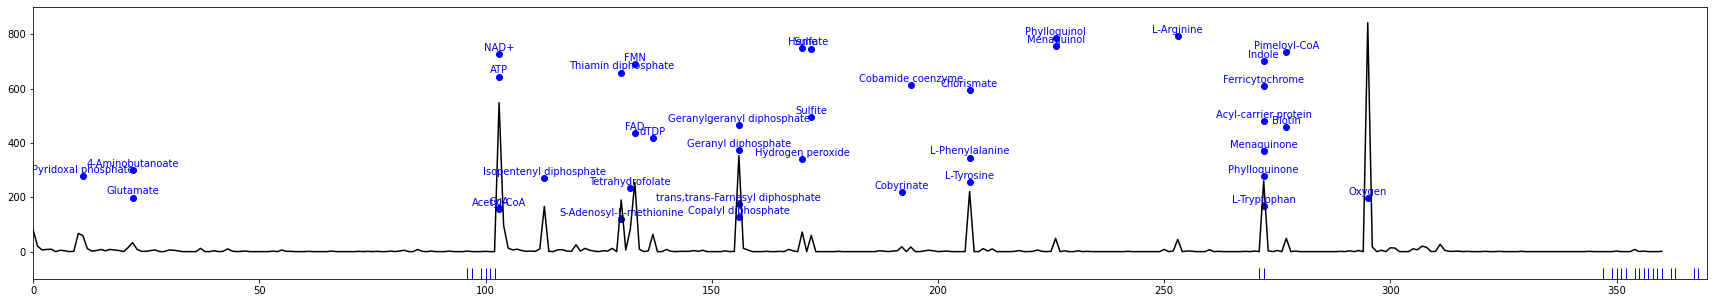

In [182]:
# without P

cpd2iter = {}
for cpd in ['C0007', 'C00018', 'C00302', 'C00334', 'C11440', 'C00002', 'C00003', 'C00010', 'C00024', 'C00129', 'C00068', 'C00019', 'C00101', 'C00016', 'C00061', 'C00363', 'C00194', 'C00062', 'C00007', 'C00448', 'C11901', 'C00341', 'C00353', 'C00923', 'C00463', 'C00229', 'C05819', 'C03313', 'C00027', 'C00032', 'C00059', 'C00094', 'C05773', 'C00251', 'C00082', 'C00079', 'C00078', 'C02059', 'C00828', 'C01063', 'C00120']:
    for folditer in folditer2cpd.keys():
        for c in folditer2cpd[folditer]:
            if c == cpd:
                cpd2iter[c] = folditer
                
plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFull.values(), color='k')

sns.rugplot(multiple, height=0.04, color='blue')  # double fold injection

# Add annotations
for key, value in cpd2iter.items():
    position = random.randint(100, 800)
    plt.text(value, position, cpd2name[key], ha='center', va='bottom', color='blue')
    plt.scatter(value, position-5, color='b')

plt.xlim([0, 370])
plt.ylim([-100, 900])
# plt.savefig('3B_cpds_multiple_injections_noP.svg', dpi=300, bbox_inches='tight')
plt.show()

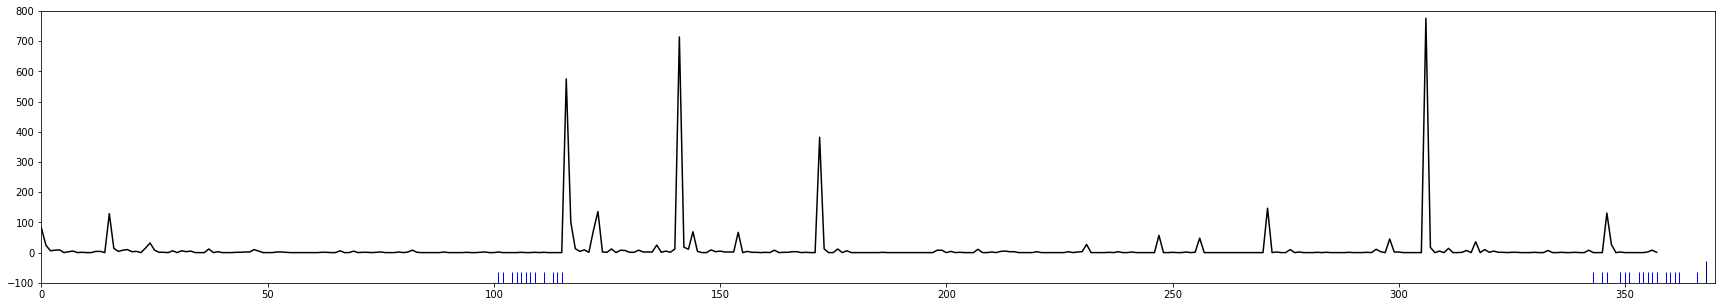

In [52]:
# with P

plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFullP.values(), color='k')

# sns.rugplot(batm.folds_folditer.values(), height=0.04)
sns.rugplot(multipleP, height=0.04, color='blue')  # double fold injection
sns.rugplot([368], height=0.08, color='#020079')  # triple fold injection

plt.xlim([0, 370])
plt.ylim([-100, 800])
# plt.savefig('3B_cpds_withP.svg', dpi=300, bbox_inches='tight')
plt.show()

In [53]:
len(multipleP)

29

In [54]:
# get info about the big peaks

for folditer, num in folditer2cpdNumFullP.items():
    if num > 100:
        print(folditer, num, folditer2foldsP[folditer])

15 129 ['218']
116 575 ['4953']
117 101 ['7524']
123 136 ['2486']
141 714 ['7501']
172 382 ['141']
271 147 ['875']
306 776 ['3997']
346 131 ['184', '7544']


# annotate folds

In [55]:
# first 10 folds, ferredoxin (X187), P-loop (X2004), X3997, 
# HUP (X2005), HAD(X2006), Nat/Ivy (X213), CLB (X1), Beta-Grasp (X221), a/b-plaits (X304)
myFolds = ['1', '187', '2004', '2006', '3997', '213', '221', '304']
first10 = ['325', '2002', '218', '206', '4953', '2003', '2007', '602', '2005', '4952']

In [56]:
myFolds2iter = {}
for x in myFolds:
    print(f"X{x}: {withP.folds_folditer[x]} {x2name.get(x, 'no X name')}")
    myFolds2iter[x] = withP.folds_folditer[x]

X1: 3 cradle loop barrel
X187: 149 alpha-helical ferredoxin-like
X2004: 49 P-loop domains-like
X2006: 5 HAD domain-like
X3997: 306 no X name
X213: 125 Nat/Ivy
X221: 97 beta-Grasp
X304: 8 Alpha-beta plaits


In [57]:
first102iter = {}
for x in first10:
    print(f"X{x}: {withP.folds_folditer[x]} {x2name.get(x, 'no X name')}")
    first102iter[x] = withP.folds_folditer[x]

X325: 33 alpha/beta-Hammerhead/Barrel-sandwich hybrid
X2002: 2 TIM beta/alpha-barrel
X218: 15 Enolase-N/ribosomal protein
X206: 32 no X name
X4953: 116 no X name
X2003: 7 Rossmann-like
X2007: 16 Flavodoxin-like
X602: 115 L-aspartase middle domain-like
X2005: 89 HUP domain-like
X4952: 115 no X name


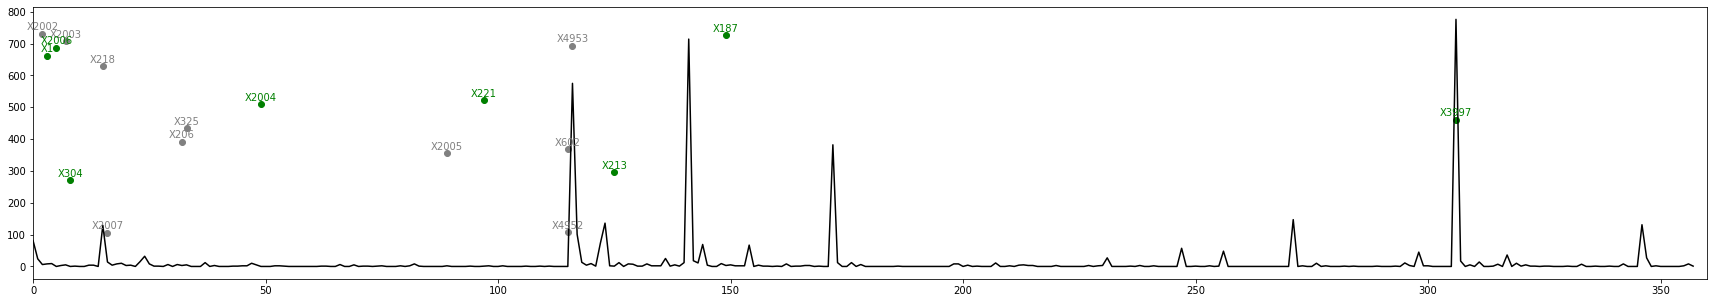

In [58]:
plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFullP.values(), color='k')

# Add annotations
for key, value in first102iter.items():
    position = random.randint(100, 800)
    plt.text(value, position, 'X'+str(key), ha='center', va='bottom', color='gray')
    plt.scatter(value, position-5, color='gray')
for key, value in myFolds2iter.items():
    position = random.randint(100, 800)
    plt.text(value, position, 'X'+str(key), ha='center', va='bottom', color='green')
    plt.scatter(value, position-5, color='green')

plt.xlim([0, 360])
# plt.savefig('3B_cpds_annotated_withP.svg', dpi=300, bbox_inches='tight')
plt.show()

In [59]:

# 221 ('beta-Grasp') is added BEFORE ATP peak... why?


In [60]:
group1 = {'3997', '1', '4011', '253', '7574', '875', '206', '3016', '328', '2486', '212', '148', '2002', '325', '4952', '218', '184', '7577', '2005', '2007', '4953', '7501', '7584', '7579', '297', '2492', '7523', '101', '141', '7544', '109', '2003', '2004', '602', '330', '304', '327'}

In [61]:
group12iter = {}
for x in group1:
    print(f"X{x}: {withP.folds_folditer[x]} {x2name.get(x, 'no X name')}")
    group12iter[x] = withP.folds_folditer[x]

X212: 56 no X name
X7501: 141 no X name
X7577: 23 no X name
X206: 32 no X name
X602: 115 L-aspartase middle domain-like
X4953: 116 no X name
X1: 3 cradle loop barrel
X148: 215 Histone-like
X253: 298 no X name
X218: 15 Enolase-N/ribosomal protein
X2492: 99 no X name
X4011: 256 no X name
X327: 165 Alpha-lytic protease prodomain-like
X2005: 89 HUP domain-like
X7579: 39 no X name
X4952: 115 no X name
X2002: 2 TIM beta/alpha-barrel
X330: 132 dsRBD-like
X141: 172 no X name
X297: 43 no X name
X2486: 123 no X name
X3997: 306 no X name
X7523: 96 no X name
X2003: 7 Rossmann-like
X328: 93 IF3-like
X7544: 346 no X name
X304: 8 Alpha-beta plaits
X875: 271 no X name
X109: 19 Repetitive alpha hairpins
X7574: 64 no X name
X3016: 24 no X name
X325: 33 alpha/beta-Hammerhead/Barrel-sandwich hybrid
X2007: 16 Flavodoxin-like
X7584: 255 no X name
X101: 106 HTH
X184: 346 no X name
X2004: 49 P-loop domains-like


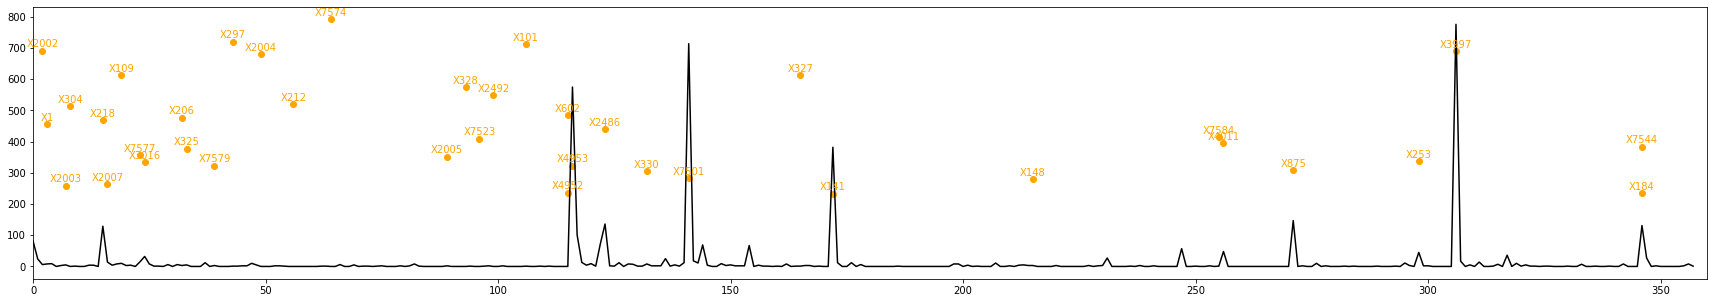

In [62]:
plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFullP.values(), color='k')

# Add annotations
for key, value in group12iter.items():
    position = random.randint(100, 800)
    plt.text(value, position, 'X'+str(key), ha='center', va='bottom', color='orange')
    plt.scatter(value, position-5, color='orange')

plt.xlim([0, 360])
# plt.savefig('3B_cpds_group1_withP.svg', dpi=300, bbox_inches='tight')
plt.show()

In [63]:
# X7544 / X184 AFTER Oxygen!

# X148: 'Histone like'  what is this doing? why did this come earlier?
    # another fold required for chlorophyll! GATED BY PROTEIN!!!!!

# X875 peak (chorismate, Phe, Tyr) is known to move around
# X2492 much earlier, BEFORE ATP!
# X330 earlier, no longer associated with a peak

# annotate cpds

In [64]:
cpd2iterP = {}

In [65]:
for cpd in ['C00448', 'C11901', 'C00341', 'C00353', 'C00923', 'C00463', 'C00229', 'C05819', 'C03313']:
    for folditer in folditer2cpdP.keys():
        for c in folditer2cpdP[folditer]:
            if c == cpd:
                print(folditer, c, cpd2name[c], len(cpd2rn[c]))
                cpd2iterP[c] = folditer

172 C00448 trans,trans-Farnesyl diphosphate 155
172 C11901 Copalyl diphosphate 11
172 C00341 Geranyl diphosphate 65
172 C00353 Geranylgeranyl diphosphate 62
164 C00923 Ferricytochrome 5
346 C00463 Indole 8
116 C00229 Acyl-carrier protein 91
271 C05819 Menaquinol 12
271 C03313 Phylloquinol 7


In [66]:
for cpd in ['C00027', 'C00032', 'C00059', 'C00094', 'C05773', 'C00251', 'C00082', 'C00079', 'C00078', 'C02059', 'C00828', 'C01063', 'C00120', 'C00018', 'C00302', 'C00334', 'C11440', 'C00002', 'C00003', 'C00010', 'C00024', 'C00129', 'C00068', 'C00019', 'C00101', 'C00016', 'C00061', 'C00363', 'C00194', 'C00062', 'C00007']:
    for folditer in folditer2cpdP.keys():
        for c in folditer2cpdP[folditer]:
            if c == cpd:
                print(folditer, c, cpd2name[c], len(cpd2rn[c]))
                cpd2iterP[c] = folditer

141 C00027 Hydrogen peroxide 333
141 C00032 Heme 18
141 C00059 Sulfate 37
141 C00094 Sulfite 47
231 C05773 Cobyrinate 5
271 C00251 Chorismate 13
271 C00082 L-Tyrosine 44
271 C00079 L-Phenylalanine 32
346 C00078 L-Tryptophan 36
271 C02059 Phylloquinone 6
271 C00828 Menaquinone 12
247 C01063 Pimeloyl-CoA 4
247 C00120 Biotin 11
15 C00018 Pyridoxal phosphate 15
24 C00302 Glutamate 2
24 C00334 4-Aminobutanoate 16
116 C00002 ATP 796
116 C00003 NAD+ 1078
116 C00010 CoA 638
116 C00024 Acetyl-CoA 218
122 C00129 Isopentenyl diphosphate 50
141 C00068 Thiamin diphosphate 28
141 C00019 S-Adenosyl-L-methionine 564
144 C00101 Tetrahydrofolate 43
141 C00016 FAD 93
141 C00061 FMN 72
154 C00363 dTDP 75
231 C00194 Cobamide coenzyme 6
298 C00062 L-Arginine 50
306 C00007 Oxygen 1638


In [67]:
for cpd in ['C00018', 'C00302', 'C00334', 'C11440', 'C00002', 'C00003', 'C00010', 'C00024', 'C00129', 'C00068', 'C00019', 'C00101', 'C00016', 'C00061', 'C00363', 'C00194', 'C00062', 'C00007']:
    for folditer in folditer2cpdP.keys():
        for c in folditer2cpdP[folditer]:
            if c == cpd:
                print(folditer, c, cpd2name[c], len(cpd2rn[c]))
                cpd2iterP[c] = folditer

15 C00018 Pyridoxal phosphate 15
24 C00302 Glutamate 2
24 C00334 4-Aminobutanoate 16
116 C00002 ATP 796
116 C00003 NAD+ 1078
116 C00010 CoA 638
116 C00024 Acetyl-CoA 218
122 C00129 Isopentenyl diphosphate 50
141 C00068 Thiamin diphosphate 28
141 C00019 S-Adenosyl-L-methionine 564
144 C00101 Tetrahydrofolate 43
141 C00016 FAD 93
141 C00061 FMN 72
154 C00363 dTDP 75
231 C00194 Cobamide coenzyme 6
298 C00062 L-Arginine 50
306 C00007 Oxygen 1638


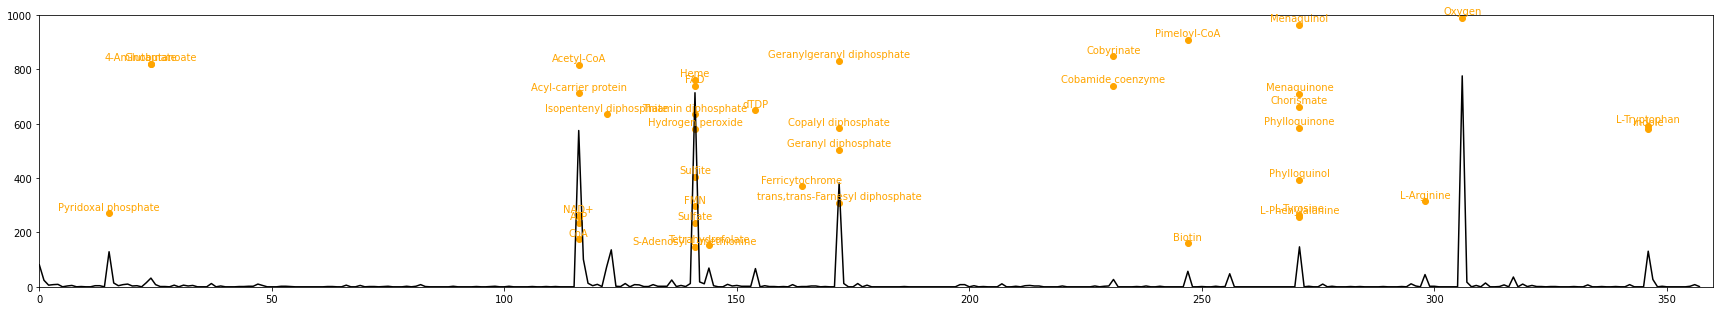

In [68]:
plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFullP.values(), color='k')

# Add annotations
for key, value in cpd2iterP.items():
    position = random.randint(100, 1000)
    plt.text(value, position, cpd2name[key], ha='center', va='bottom', color='orange')
    plt.scatter(value, position-5, color='orange')

plt.xlim([0, 360])
plt.ylim([0, 1000])
# plt.savefig('3B_cpds_annotated_withP.svg', dpi=300, bbox_inches='tight')
plt.show()

In [69]:
# Acyl-carrier protein WITH CoA

# new big peak at 141 = 5 peaks combined (SAM/thiamine + THFolate + FAD/FMN + Heme/H2O2 + sulfate/sulfite)
#    fold is X7501, Dihydrofolate reductases (Group1)
#            Riboflavin biosynthesis & Tetrahydrofolate biosynthesis (makes THF and FAD/FMN)
#            a/b three-layered sandwiches

# Ferricytochrome much earlier, no longer with quinones
# biotin / pimeloyl-CoA peak slightly earlier

# X875 peak (chorismate, Phe, Tyr) now coincides with quinone peak, but smaller because no more "protein" cpds
# also does not have Trp... which moved after O2! (doublet)


In [70]:
cpd2iterZ = {}

for folditer in folditer2cpdP.keys():
    for c in folditer2cpdP[folditer]:
        if c.startswith('Z'):
            cpd2iterZ[c] = folditer

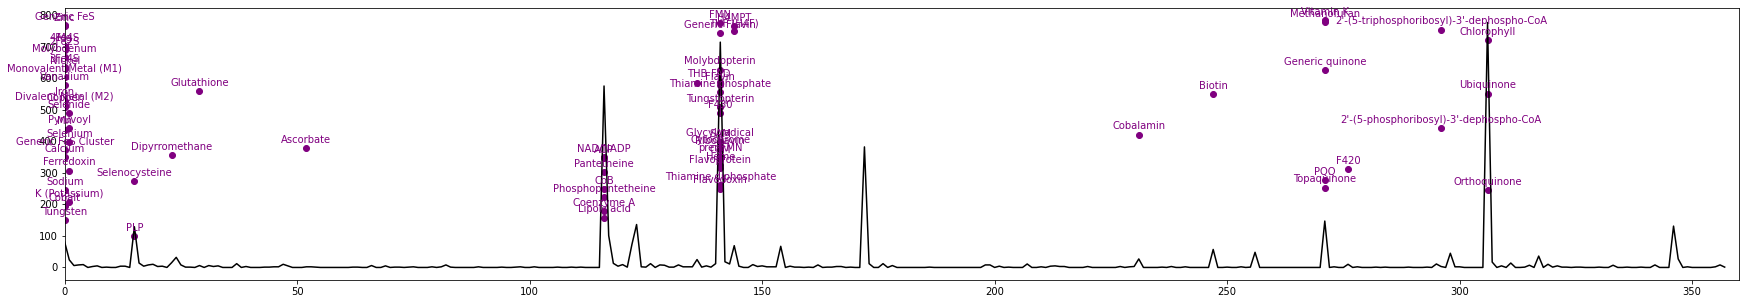

In [71]:
plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFullP.values(), color='k')

# Add annotations
for key, value in cpd2iterZ.items():
    position = random.randint(100, 800)
    plt.text(value, position, zpd2name[key], ha='center', va='bottom', color='purple')
    plt.scatter(value, position-10, color='purple')

plt.xlim([0, 360])
# plt.savefig('3B_cpds_Z.svg', dpi=300, bbox_inches='tight')
plt.show()

In [72]:
aa = ['C00077', 'C00041', 'C00097', 'C00049', 'C00025', 'C00079', 'C00079', 'C00135', 'C00407', 'C00047', 'C00123', 'C00073', 'C00152', 'C00148', 'C00064', 'C00062', 'C00065', 'C00188', 'C00183', 'C00078', 'C00082']
nuc = ['C00147', 'C00475', 'C00242', 'C00178', 'C00002', 'C00063', 'C00044', 'C00075', 'C00131', 'C00458', 'C00459', 'C00286']

In [73]:
cpd2iterAA = {}
cpd2iterNuc = {}

In [74]:
for cpd in aa:
    for folditer in folditer2cpdP.keys():
        for c in folditer2cpdP[folditer]:
            if c == cpd:
                print(folditer, c, cpd2name[c], len(cpd2rn[c]))
                cpd2iterAA[c] = folditer
            
for cpd in nuc:
    for folditer in folditer2cpdP.keys():
        for c in folditer2cpdP[folditer]:
            if c == cpd:
                print(folditer, c, cpd2name[c], len(cpd2rn[c]))
                cpd2iterNuc[c] = folditer

117 C00077 L-Ornithine 25
0 C00041 L-Alanine 60
15 C00097 L-Cysteine 57
0 C00049 L-Aspartate 48
0 C00025 L-Glutamate 223
271 C00079 L-Phenylalanine 32
271 C00079 L-Phenylalanine 32
141 C00135 L-Histidine 29
0 C00407 L-Isoleucine 14
116 C00047 L-Lysine 42
0 C00123 L-Leucine 8
141 C00073 L-Methionine 100
12 C00152 L-Asparagine 10
0 C00148 L-Proline 18
15 C00064 L-Glutamine 53
298 C00062 L-Arginine 50
0 C00065 L-Serine 48
0 C00188 L-Threonine 14
0 C00183 L-Valine 11
346 C00078 L-Tryptophan 36
271 C00082 L-Tyrosine 44
116 C00147 Adenine 18
141 C00475 Cytidine 21
116 C00242 Guanine 7
154 C00178 Thymine 12
116 C00002 ATP 796
141 C00063 CTP 64
116 C00044 GTP 62
141 C00075 UTP 43
116 C00131 dATP 14
141 C00458 dCTP 8
154 C00459 dTTP 13
116 C00286 dGTP 10


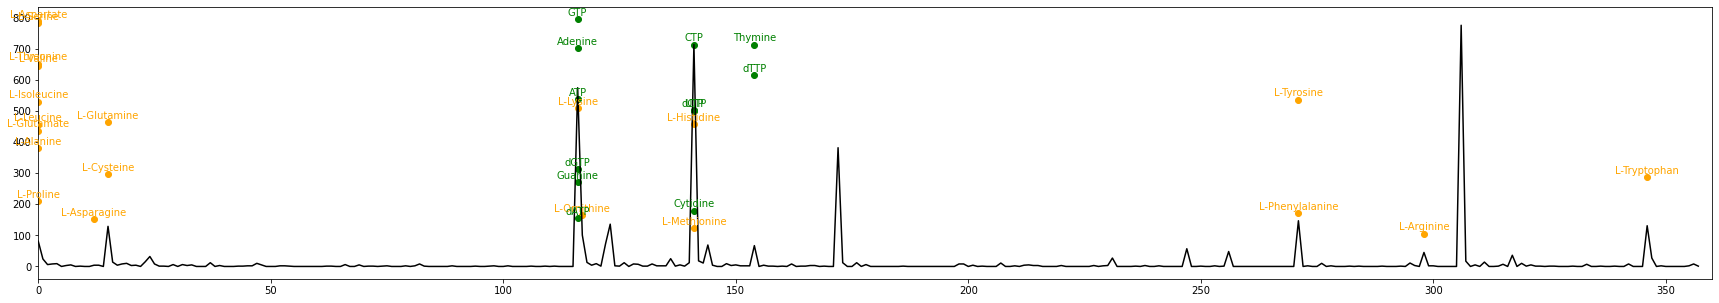

In [75]:
plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFullP.values(), color='k')

# Add annotations
for key, value in cpd2iterAA.items():
    position = random.randint(100, 800)
    plt.text(value, position, cpd2name[key], ha='center', va='bottom', color='orange')
    plt.scatter(value, position-5, color='orange')
for key, value in cpd2iterNuc.items():
    position = random.randint(100, 800)
    plt.text(value, position, cpd2name[key], ha='center', va='bottom', color='green')
    plt.scatter(value, position-5, color='green')

plt.xlim([0, 360])
# plt.savefig('3B_cpds_AA_Nuc.svg', dpi=300, bbox_inches='tight')
plt.show()

# PCA

In [76]:
withP.folds_folditer

{'fold_independent': 0,
 'spontaneous': 1,
 '2002': 2,
 '1': 3,
 '2487': 4,
 '2006': 5,
 '246': 6,
 '2003': 7,
 '304': 8,
 '4126': 9,
 '62': 10,
 '7518': 11,
 '210': 12,
 '7542': 13,
 '7525': 14,
 '218': 15,
 '2007': 16,
 '12': 17,
 '11': 18,
 '109': 19,
 '10': 20,
 '7515': 21,
 '279': 22,
 '7577': 23,
 '3016': 24,
 '281': 25,
 '7528': 26,
 '331': 27,
 '7572': 28,
 '2011': 29,
 '301': 30,
 '282': 31,
 '206': 32,
 '325': 33,
 '805': 34,
 '7527': 35,
 '3691': 36,
 '7560': 37,
 '7529': 38,
 '7579': 39,
 '7512': 40,
 '180': 41,
 '70': 42,
 '297': 43,
 '315': 44,
 '286': 45,
 '4002': 46,
 '205': 47,
 '2485': 48,
 '2004': 49,
 '7554': 50,
 '7580': 51,
 '247': 52,
 '3156': 53,
 '5': 54,
 '7571': 55,
 '212': 56,
 '5104': 57,
 '387': 58,
 '7510': 59,
 '2': 60,
 '208': 61,
 '7567': 62,
 '307': 63,
 '7574': 64,
 '7516': 65,
 '7561': 66,
 '7517': 67,
 '7573': 68,
 '185': 69,
 '164': 70,
 '7552': 71,
 '4021': 72,
 '298': 73,
 '149': 74,
 '810': 75,
 '2493': 76,
 '2498': 77,
 '4081': 78,
 '611': 79,

In [77]:
data_path = '../fold_iters_pre_expansion.csv'
with open(data_path, 'r') as file:
    lines = file.readlines()

xgroups = []
for line in lines:
    if line[0] == ',':
        xgroups = line.split(',')[1:-3]
        break

In [78]:
# re-order to fit fold_iters_pre-expansion.csv
x2fo_withP = {}

for x in xgroups:
    x2fo_withP[x] = withP.folds_folditer[x]

In [79]:
# dict2csv(x2fo_withP, 'x2fo_withP.csv') 

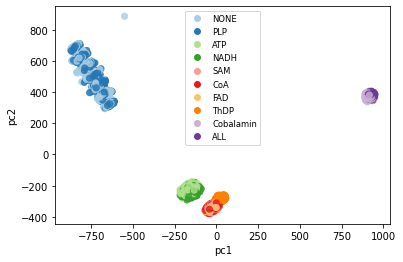

In [80]:
# add "withP" run

data_path = '../fold_iters_pre_expansion_withP.csv'
with open(data_path, 'r') as file:
    lines = file.readlines()

data = []  # 10,001 * 397
labels = []  # 10,001
for line in lines:
    if line[0] == ',':
        continue
    fo = line.split(',')[3:-3]
    pre = line.split(',')[-1].strip()  # pre-expansion labels
    data.append(fo)
    labels.append(pre)
np.array(data)
df = pd.DataFrame(data, index=labels)

label_colors = {'NONE': '#A6CEE3', 'C00002': '#B1E08A', 'C00004': '#31A12C', 'C00010': '#E21C1C', 'C00016': '#FDC16E', 'C00019': '#FB9B98', 'Z00009': '#CAB2D6', 'Z00035': '#2576B4', 'Z00047': '#FF8000', 'ALL': '#6B3A99'}
label_colors2 = {'NONE': 'NONE', 'Z00035': 'PLP', 'C00002': 'ATP', 'C00004': 'NADH', 'C00019': 'SAM', 'C00010': 'CoA', 'C00016': 'FAD', 'Z00047': 'ThDP', 'Z00009': 'Cobalamin', 'ALL': 'ALL'}
# Map index values to their corresponding colors
colors_by_label = df.index.map(label_colors)

pca = PCA(n_components=2)
principal_components = pca.fit_transform(data)

# Create a scatter plot with colored points based on the index labels
plt.scatter(principal_components[:, 0], principal_components[:, 1], c=colors_by_label, alpha=0.8)
    
plt.xlabel('pc1')
plt.ylabel('pc2')
legend_labels = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=label_colors[label], markersize=8, label=label_colors2[label]) for label in label_colors2.keys()]
plt.legend(handles=legend_labels, loc="upper center", fontsize='small')
# plt.savefig('PCA_withP.png')
plt.show()

## compare fold/cpd/rn orders

In [81]:
x2fo_withP

{'fold_independent': 0,
 'spontaneous': 1,
 '2002': 2,
 '1': 3,
 '2487': 4,
 '2006': 5,
 '2003': 7,
 '246': 6,
 '7525': 14,
 '218': 15,
 '2007': 16,
 '304': 8,
 '12': 17,
 '11': 18,
 '109': 19,
 '10': 20,
 '210': 12,
 '7515': 21,
 '279': 22,
 '7577': 23,
 '3016': 24,
 '281': 25,
 '7528': 26,
 '331': 27,
 '7542': 13,
 '301': 30,
 '7572': 28,
 '2011': 29,
 '325': 33,
 '206': 32,
 '282': 31,
 '7527': 35,
 '805': 34,
 '7529': 38,
 '7512': 40,
 '3691': 36,
 '7518': 11,
 '7579': 39,
 '62': 10,
 '4126': 9,
 '7560': 37,
 '180': 41,
 '7554': 50,
 '315': 44,
 '70': 42,
 '297': 43,
 '7580': 51,
 '4002': 46,
 '286': 45,
 '2004': 49,
 '205': 47,
 '7561': 66,
 '7517': 67,
 '7574': 64,
 '387': 58,
 '7571': 55,
 '5': 54,
 '247': 52,
 '7567': 62,
 '212': 56,
 '7510': 59,
 '5104': 57,
 '307': 63,
 '2': 60,
 '208': 61,
 '7516': 65,
 '7573': 68,
 '328': 93,
 '611': 79,
 '4021': 72,
 '298': 73,
 '7520': 87,
 '164': 70,
 '2498': 77,
 '4081': 78,
 '3651': 90,
 '810': 75,
 '2485': 48,
 '149': 74,
 '632': 98,


In [82]:
x2foAveNONE = csv2dict('../data/assets/xgroup2/xgroup2foAveNONE.csv')

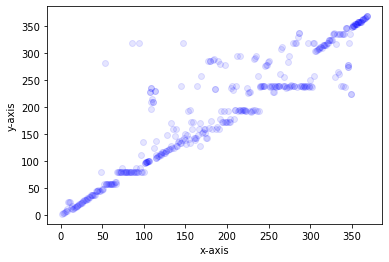

In [83]:
scatter(x2fo_withP, x2foAveNONE)  # compare with average foNONE

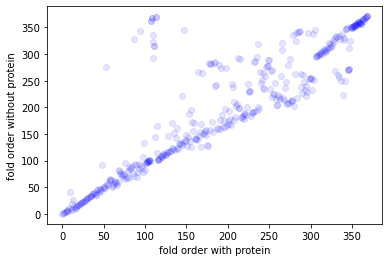

In [84]:
scatter(withP.folds_folditer, batm.folds_folditer, 'fold order with protein', 'fold order without protein')

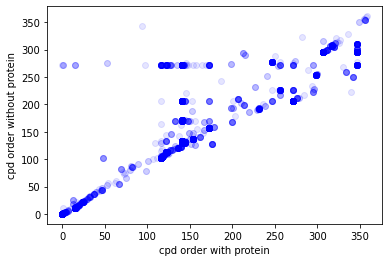

In [85]:
scatter(withP.cpds_folditer, batm.cpds_folditer, 'cpd order with protein', 'cpd order without protein')

In [86]:
# try using bokeh

from bokeh.plotting import figure, output_file, show
from bokeh.models import HoverTool

# Create a new plot
output_file("annotated_plot.html")
p = figure(plot_width=800, plot_height=800, title="fold order (with protein) vs. fold order (no protein)")

# Add annotations
# source = {'x': list(group12iter.values()), 'y': y_values, 'label': ['X' + str(key) for key in group12iter.keys()]}
key, data1, data2 = todata(withP.folds_folditer, batm.folds_folditer)
source = {'x': data1, 'y': data2, 'label': [f"X{key} " + x2name.get(key, 'no X name') for key in key]}
p.scatter('x', 'y', source=source, size=10, color='blue')

# Add hover tool
hover = HoverTool()
hover.tooltips = [("folditer", "@x"), ("fold", "@label")]
p.add_tools(hover)

# Customize plot
p.xaxis.axis_label = 'fold order (with protein)'
p.yaxis.axis_label = 'fold order (no protein)'
p.xaxis.ticker = [50, 100, 150, 200, 250, 300, 350]  # Convert range to list
p.xgrid.grid_line_color = None

# Show the plot
show(p)

In [87]:
zcpd2name = {}
for c, name in zpd2name.items():
    zcpd2name[c] = name
for c, name in cpd2name.items():
    zcpd2name[c] = name  

In [88]:
# try using bokeh

from bokeh.plotting import figure, output_file, show
from bokeh.models import HoverTool

# Create a new plot
output_file("annotated_plot.html")
p = figure(plot_width=800, plot_height=800, title="cpd order (with protein) vs. cpd order (no protein)")

# Add annotations
# source = {'x': list(group12iter.values()), 'y': y_values, 'label': ['X' + str(key) for key in group12iter.keys()]}
key, data1, data2 = todata(withP.cpds_folditer, batm.cpds_folditer)
source = {'x': data1, 'y': data2, 'label': [zcpd2name.get(key, '?') for key in key]}
p.scatter('x', 'y', source=source, size=10, color='blue')

# Add hover tool
hover = HoverTool()
hover.tooltips = [("folditer", "@x"), ("cpd", "@label")]
p.add_tools(hover)

# Customize plot
p.xaxis.axis_label = 'cpd order (with protein)'
p.yaxis.axis_label = 'cpd order (no protein)'
p.xaxis.ticker = [50, 100, 150, 200, 250, 300, 350]  # Convert range to list
p.xgrid.grid_line_color = None

# Show the plot
show(p)

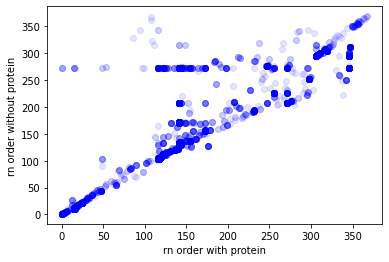

In [89]:
scatter(withP.rns_folditer, batm.rns_folditer, 'rn order with protein', 'rn order without protein')

# variability of major peaks

In [90]:
label = 'NONE'
df_optimal = pd.read_csv(f'../cpds_folditer_pre-expansion_1000runs/cpds_folditer_pre-expansion_1000runs_{label}.csv', index_col=0)

In [91]:
df_optimal.head()

,23193,32989,47510,54322,46853,27496,64303,20109,51816,48274,...,3089,37378,54274,48974,14168,36090,7077,22732,63183,53542
C20679,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Z00055,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
C00069,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
C00407,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
C00009,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [92]:
def histo(c):
    print(cpd2name[c])
    print(np.mean(df_optimal.loc[c]), np.std(df_optimal.loc[c]))
    plt.hist(list(df_optimal.loc[c]), bins= 50, edgecolor='none')

    plt.xlabel('folditer')
    plt.ylabel('# runs')
    plt.xlim([0, 370])
    plt.show()

ATP
107.619 2.946156648924154


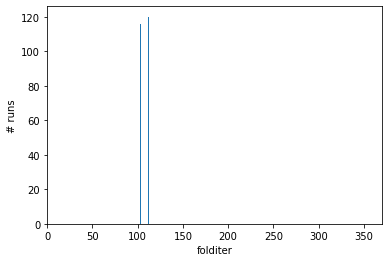

In [93]:
histo('C00002')

Isopentenyl diphosphate
117.619 2.946156648924154


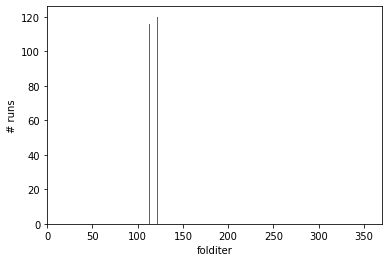

In [94]:
histo('C00129')

S-Adenosyl-L-methionine
132.925 3.1287976924051835


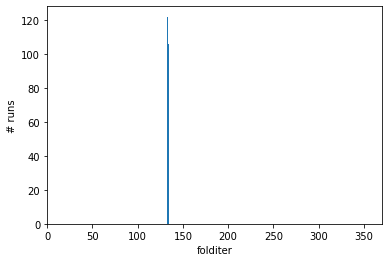

In [95]:
histo('C00019')

Tetrahydrofolate
135.246 2.9521998577332127


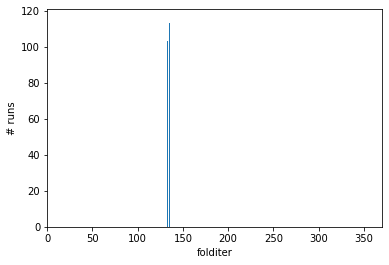

In [96]:
histo('C00101')

FAD
136.405 2.9060239159373755


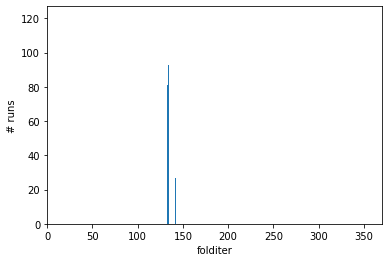

In [97]:
histo('C00016')

dTDP
140.405 2.9060239159373755


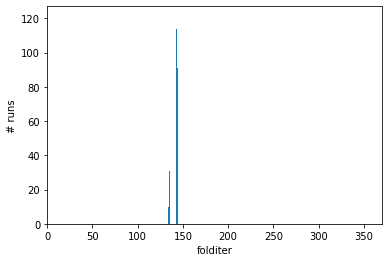

In [98]:
histo('C00363')

Hydrogen peroxide
170.905 3.5213598225685487


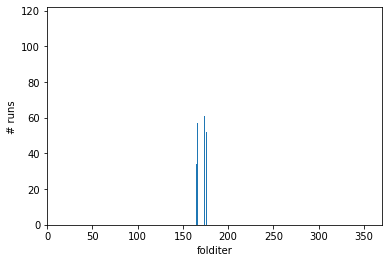

In [99]:
histo('C00027')

trans,trans-Farnesyl diphosphate
159.084 3.2946842033797417


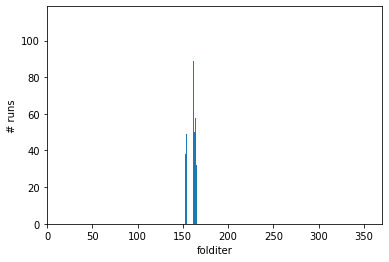

In [100]:
histo('C00448')  # 'fastest' run is late! folditer=172

L-Phenylalanine
235.79 18.067205096527797


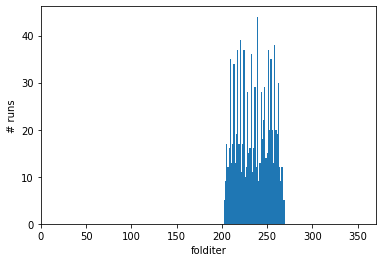

In [101]:
histo('C00079')

Menaquinol
243.492 14.664990146604257


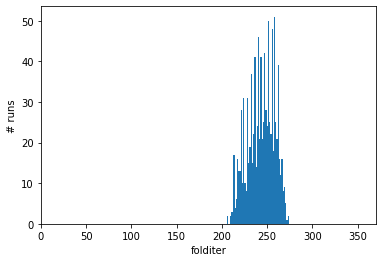

In [102]:
histo('C05819')

L-Arginine
238.105 18.243080194967074


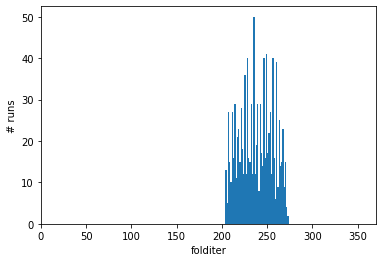

In [103]:
histo('C00062')

Menaquinone
277.667 3.104208594795137


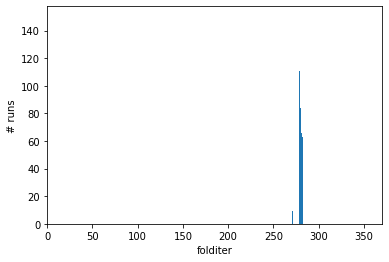

In [104]:
histo('C00828')

Acyl-carrier protein
277.667 3.104208594795137


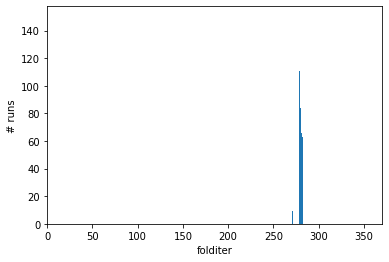

In [105]:
histo('C00229')

L-Tryptophan
277.667 3.104208594795137


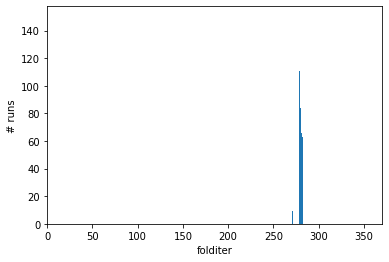

In [106]:
histo('C00078')

Biotin
277.778 3.391270558360097


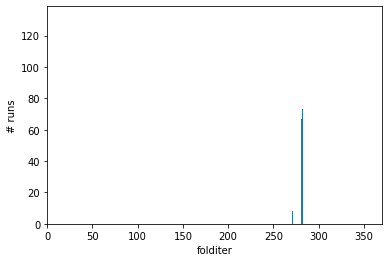

In [107]:
histo('C00120')

Oxygen
304.303 5.128273686144296


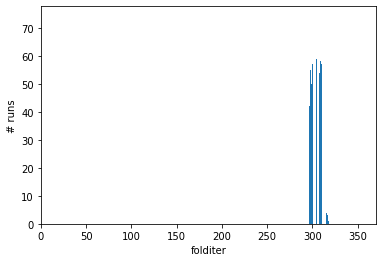

In [108]:
histo('C00007')

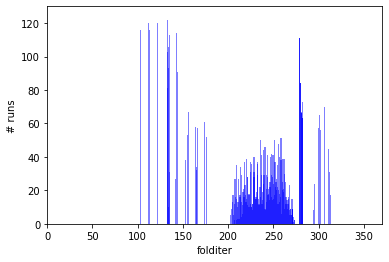

In [109]:
for c in ['C00002', 'C00129', 'C00019', 'C00101', 'C00016', 'C00363', 'C00027', 'C00448', 'C00079', 'C05819', 'C00062', 'C00828', 'C00229', 'C00078', 'C00120', 'C00007']:
    plt.hist(list(df_optimal.loc[c]), bins= 50, edgecolor='none', alpha=0.5, color='b')

plt.xlabel('folditer')
plt.ylabel('# runs')
plt.xlim([0, 370])
plt.ylim([0, 130])
plt.show()

In [110]:
# #f44336, #e81e63, #9c27b0, #673ab7, #3f51b5, #2196f3, #03a9f4, #00bcd4, #009688, #4caf50, #8bc34a, #cddc39, #ffeb3b, #ffc107, #ff9800, #ff5722

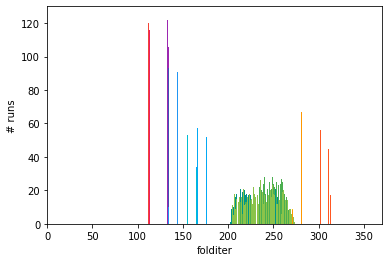

In [111]:
colors= ['#f44336', '#e81e63', '#9c27b0', '#673ab7', '#3f51b5', '#2196f3', '#03a9f4', '#00bcd4', '#009688', '#4caf50', '#8bc34a', '#cddc39', '#ffeb3b', '#ffc107', '#ff9800', '#ff5722']
i = 0

for c in ['C00002', 'C00129', 'C00019', 'C00101', 'C00016', 'C00363', 'C00027', 'C00448', 'C00079', 'C05819', 'C00062', 'C00828', 'C00229', 'C00078', 'C00120', 'C00007']:
    plt.hist(list(df_optimal.loc[c]), bins= 100, edgecolor='none', alpha=1, color = colors[i])
    i += 1

plt.xlabel('folditer')
plt.ylabel('# runs')
plt.xlim([0, 370])
plt.ylim([0, 130])
plt.show()

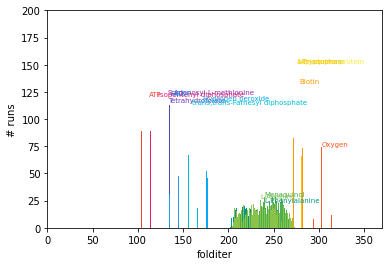

In [180]:
colors= ['#f44336', '#e81e63', '#9c27b0', '#673ab7', '#3f51b5', '#2196f3', '#03a9f4', '#00bcd4', '#009688', '#4caf50', '#8bc34a', '#cddc39', '#ffeb3b', '#ffc107', '#ff9800', '#ff5722']
i = 0

fig, ax = plt.subplots()
for c in ['C00002', 'C00129', 'C00019', 'C00101', 'C00016', 'C00363', 'C00027', 'C00448', 'C00079', 'C05819', 'C00062', 'C00828', 'C00229', 'C00078', 'C00120', 'C00007']:
#     plt.hist(list(df_optimal.loc[c]), bins= 100, edgecolor='none', alpha=1, color = colors[i])
#     i += 1
    
    counts, bins, patches = ax.hist(list(df_optimal.loc[c]), bins=100, edgecolor='none', alpha=1, color=colors[i])
    # Calculate the position for the annotation
    max_count = max(counts)
    max_bin = bins[counts.argmax()]

    ax.annotate(cpd2name[c], xy=(max_bin, max_count), xytext=(max_bin, max_count + 1),
                fontsize=7,
                color=colors[i],  # Set the text color here
                )
    i += 1

plt.xlabel('folditer')
plt.ylabel('# runs')
plt.xlim([0, 370])
plt.ylim([0, 200])
plt.savefig('peak_variability_before2.svg', dpi=300, bbox_inches='tight')
plt.show()

# Which reactions came much earlier?

In [114]:
# 15 129 ['218']    PLP
# 116 575 ['4953']  purine
# 117 101 ['7524']  purine
# 123 136 ['2486']  IPP
# 141 714 ['7501']  MEGA peak
# 172 382 ['141']   terpenes
# 271 147 ['875']   Phe/Tyr/quinone
# 306 776 ['3997']  Oxygen
# 346 131 ['184', '7544']  Trp

In [115]:
check = {}

for c in proteinAt272:
    print('------------')
    print(c, cpd2name[c])
    print('------------')
    for rn in cpd2rn[c]:
        print(batm.rns_folditer.get(rn, 'rn not discovered'), withP.rns_folditer.get(rn, 'rn not discovered'))
        if withP.rns_folditer.get(rn, 10000) < 116:  # if 'protein' rn came before purine synth
            check[rn] = [batm.rns_folditer.get(rn, 'rn not discovered'), withP.rns_folditer.get(rn, 'rn not discovered')]

------------
C22368 5-Methyl-3-oxohexanoyl-[acyl-carrier-protein]
------------
272 116
------------
C16220 (3R)-3-Hydroxyoctadecanoyl-[acyl-carrier protein]
------------
272 126
272 126
272 295
------------
C00685 3-Oxoacyl-[acyl-carrier protein]
------------
272 122
272 122
272 122
272 122
------------
C04088 Octadecanoyl-[acyl-carrier protein]
------------
272 295
272 295
rn not discovered rn not discovered
------------
C04618 (3R)-3-Hydroxybutanoyl-[acyl-carrier protein]
------------
272 141
272 141
272 122
------------
C03024 [Reduced NADPH---hemoprotein reductase]
------------
295 306
rn not discovered rn not discovered
rn not discovered rn not discovered
rn not discovered rn not discovered
rn not discovered rn not discovered
rn not discovered rn not discovered
rn not discovered rn not discovered
rn not discovered rn not discovered
rn not discovered rn not discovered
rn not discovered rn not discovered
295 306
rn not discovered rn not discovered
rn not discovered rn not discovered

------------
C00229 Acyl-carrier protein
------------
272 256
344 116
272 141
344 116
272 296
272 116
272 126
272 122
295 306
rn not discovered rn not discovered
272 141
272 117
rn not discovered rn not discovered
rn not discovered rn not discovered
272 141
272 256
272 141
272 141
272 141
272 141
272 141
rn not discovered rn not discovered
rn not discovered rn not discovered
272 122
272 123
272 122
272 122
272 122
272 123
272 141
272 117
272 126
rn not discovered rn not discovered
rn not discovered rn not discovered
272 142
rn not discovered rn not discovered
rn not discovered rn not discovered
rn not discovered rn not discovered
272 295
272 116
272 116
rn not discovered rn not discovered
rn not discovered rn not discovered
272 141
272 122
272 116
272 117
272 117
272 296
272 141
272 141
272 141
272 141
272 141
277 247
277 247
rn not discovered rn not discovered
347 343
344 296
rn not discovered rn not discovered
rn not discovered rn not discovered
rn not discovered rn not discovered
27

In [116]:
for rn,v in check.items():
    print(f"{rn} {v} {rn2eqn_SI[rn]} | {rn2rules.get(rn, 'NOT in rn2rules')}")

RZ_116 [272, 1] Z00002 + C00017 => Z00016 | NOT in rn2rules
RZ_517 [344, 94] C00017 => C03688 | {frozenset({'132'})}
azurin_syn1 [275, 53] C00017 + Z00070 => C05357 | {frozenset({'3156'})}
azurin_syn2 [275, 53] C00017 + Z00070 => C05358 | {frozenset({'3156'})}
pro_disulf_syn [272, 15] C00017 + C00097 => C02582 | NOT in rn2rules
pro_thiol_syn [272, 15] C00017 + C00097 => C02315 | NOT in rn2rules
sulfurcarrier_syn [272, 97] C00017 + C00017 => C15810 + C15810 | {frozenset({'221'})}
thiolprot_syn [272, 1] C00017 => C15814 | NOT in rn2rules
thioredoxin1_syn [272, 1] C00017 => C00343 | NOT in rn2rules
thioredoxin2_syn [272, 1] C00017 => C00342 | NOT in rn2rules
R03915 [272, 48] 2C00051 + C02582 => C02315 + C00127 | {frozenset({'2485'})}
R10610_v1 [272, 15] C01005 + C15814 + Z00035 => C20729 + C00009 + Z00035 | {frozenset({'2003'})}
R11524_v1 [272, 99] C00097 + C15810 + Z00054 => C21437 + C00001 + Z00054 | {frozenset({'2492'})}
R11523_v1 [272, 15] C21437 + Z00054 => C20729 + Z00054 | {frozens

In [117]:
for x in ['132', '3156', '221', '2485', '2003', '2492']:
    print(f"[{batm.folds_folditer[x]}, {withP.folds_folditer[x]}] X{x}")

[344, 94] X132
[275, 53] X3156
[106, 97] X221
[91, 48] X2485
[6, 7] X2003
[133, 99] X2492


In [118]:
for c in ['Z00016', 'C03688', 'C05357', 'C05358', 'C02582', 'C02315', 'C15810', 
          'C15814', 'C00343', 'C00342', 'C00127', 'C20729', 'C21437']:
    try:
        print([batm.cpds_folditer[c], withP.cpds_folditer[c]], c, cpd2name[c])
    except:
        print([batm.cpds_folditer[c], withP.cpds_folditer[c]], c, zpd2name[c])

[11, 1] Z00016 Ferredoxin
[344, 94] C03688 Apo-[acyl-carrier protein]
[275, 53] C05357 Oxidized azurin
[275, 53] C05358 Reduced azurin
[272, 15] C02582 Protein disulfide
[272, 15] C02315 Protein dithiol
[272, 97] C15810 Sulfur-carrier protein
[272, 1] C15814 Thiocarboxy-[sulfur-carrier protein]
[272, 1] C00343 Thioredoxin disulfide
[272, 1] C00342 Thioredoxin
[103, 48] C00127 Glutathione disulfide
[272, 15] C20729 [Sulfur-carrier protein]-Gly-NH-CH2-C(O)-S-L-cysteine
[272, 15] C21437 [Sulfur-carrier protein]-Gly-Gly-L-Cys


In [119]:
# what reactions are they involved in?
for c in ['Z00016', 'C03688', 'C05357', 'C05358', 'C02582', 'C02315', 'C15810', 
          'C15814', 'C00343', 'C00342', 'C00127', 'C20729', 'C21437']:
    print(c, cpd2rn.get(c, 'not in cpd2rn'))

Z00016 not in cpd2rn
C03688 ['R01623_v1', 'R01625_v1', 'R10706_v1', 'RZ_517']
C05357 ['R00785_v1', 'R00785_v2', 'R02675_v1', 'R05751_v1', 'R05751_v2', 'R09480_v1', 'R11194_v1', 'R12133_v1', 'R12134_v1', 'R12653_v1', 'azurin_syn1']
C05358 ['R00785_v1', 'R00785_v2', 'R02675_v1', 'R05751_v1', 'R05751_v2', 'R09480_v1', 'R11194_v1', 'R12133_v1', 'R12134_v1', 'R12653_v1', 'azurin_syn2']
C02582 ['R00861_v1', 'R03913', 'R03914', 'R03915', 'pro_disulf_syn']
C02315 ['R00861_v1', 'R03913', 'R03914', 'R03915', 'pro_thiol_syn']
C15810 ['R07459_v1', 'R09395', 'R10247', 'R11524_v1', 'sulfurcarrier_syn']
C15814 ['R07461_v1', 'R09395', 'R10247', 'R10610_v1', 'thiolprot_syn']
C00343 ['R02014_v1', 'R02016_v1', 'R02017_v1', 'R02017_v2', 'R02017_v3', 'R02018_v1', 'R02018_v2', 'R02018_v3', 'R02019_v1', 'R02019_v2', 'R02019_v3', 'R02020_v1', 'R02021', 'R02022_v1', 'R02023_v1', 'R02024_v1', 'R02024_v2', 'R02024_v3', 'R02025_v1', 'R02026', 'R03105_v1', 'R04120', 'R04294_v1', 'R04294_v2', 'R04294_v3', 'R04315_v

In [120]:
for rn, eqn in rn2eqn_SI.items():
    if 'Z00016' in eqn:
        if withP.rns_folditer.get(rn, 'not discovered') != 'not discovered':
            print(rn, withP.rns_folditer[rn])

R01195_v1 141
R03559_v1 319
R03678_v1 309
R03678_v4 309
R05424_v1 319
R05425_v1 319
R05426_v1 319
R05427_v1 319
R05444_v1 306
R05666_v1 318
R05817_v2 309
R05884_v1 122
R05884_v2 122
R07709_v1 319
R07710_v1 319
R08210_v1 122
R08210_v2 122
R09466_v1 141
R09513_v1 319
R10331_v1 172
R11007_v1 306
R11008_v1 306
R11711_v3 308
R11712_v3 308
R11713_v3 308
R11805_v1 306
RZ_110 15
RZ_111 47
RZ_112 15
RZ_113 47
RZ_116 1


In [121]:
for rn in ['RZ_110', 'RZ_111', 'RZ_112', 'RZ_113']:
    print(f"{rn} {rn2eqn_SI[rn]} | {rn2rules.get(rn, 'NOT in rn2rules')}")

RZ_110 C22151 => Z00016 | NOT in rn2rules
RZ_111 C00138 => Z00016 | NOT in rn2rules
RZ_112 C22150 => Z00016 | NOT in rn2rules
RZ_113 C00139 => Z00016 | NOT in rn2rules


In [122]:
cpd2name['C22151'], cpd2name['C00138']

('Oxidized [2Fe-2S] ferredoxin', 'Reduced ferredoxin')

# Trp -> protein -> Oxygen?

In [123]:
x2rn['3997']

['R03877']

In [124]:
for rn in ['R03877']:
    reac = rn2eqn_SI[rn].split(' => ')[0].split(' + ')
    prod = rn2eqn_SI[rn].split(' => ')[1].split(' + ')
    print(batm.rns_folditer[rn], rn, rn2eqn_SI[rn], rn2reversible[rn])
    print('left:')
    for c in reac:
        print(f"   {batm.cpds_folditer[c[-6:]]} {c[-6:]} {zcpd2name[c[-6:]]}")
    print('right:')
    for c in prod:
        print(f"   {batm.cpds_folditer[c[-6:]]} {c[-6:]} {zcpd2name[c[-6:]]}")
    print('======================')

295 R03877 2C00080 + C00008 + C00009 + C03516 => C00002 + C02191 + C00305 + C00001 True
left:
   0 C00080 H+
   103 C00008 ADP
   0 C00009 Orthophosphate
   295 C03516 Magnesium protoporphyrin
right:
   103 C00002 ATP
   170 C02191 Protoporphyrin
   0 C00305 Magnesium cation
   0 C00001 H2O


In [125]:
# why does it take so long? 

In [126]:
rn2rules['R03877']

{frozenset({'109', '148', '2004', '2007', '3997'})}

In [127]:
batm.rns_folditer['R03816_v1']

272

In [128]:
for x in ['109', '148', '2004', '2007', '3997']:
    print(x, batm.folds_folditer[x], withP.folds_folditer[x])

109 17 19
148 291 215
2004 48 49
2007 11 16
3997 295 306


In [129]:
# oxygen is also gated by X148!!! 

In [130]:
# X148 |ds_a/b/e= 1.0 1.0 1.0 |fo=294.5 |ns=3329 |#rn=10 |grp1 |aux |Xname=Histone-like
#      |M00529: Denitrification, nitrate => nitrogen |O2=0:0/7 |alpha arrays

# in withP, X148 is injected early. But why no early O2 discovery?

In [131]:
x2rn_required2 = {}
for x, rns in x2rn_required.items():
    new_rns = set()
    for rn in rns:
        new_rns.add(rn[:6])
    x2rn_required2[x] = list(new_rns)

In [132]:
x2rn_required2

{'7553': ['MeCoba', 'R04148', 'R10608'],
 '2487': ['R10688',
  'R11964',
  'R11263',
  'R04371',
  'R10396',
  'R09325',
  'R03444',
  'R01325',
  'R11941',
  'R00206',
  'R09326',
  'R08641',
  'R05677',
  'R10170',
  'R00339',
  'R10949',
  'R03069',
  'R08624',
  'R09720',
  'R10948',
  'R10394',
  'R03896',
  'R09188',
  'R04425',
  'R00575',
  'R10395',
  'R08628',
  'R00008',
  'R08634',
  'R10392',
  'R00350',
  'R03898',
  'R01324',
  'R00149',
  'R00199',
  'R03968',
  'R10687',
  'R05802',
  'R02628',
  'R08620',
  'R11673',
  'R10951',
  'R08645',
  'R11181',
  'R11408',
  'R01900',
  'R10393',
  'R07641',
  'R11662',
  'R09350',
  'R10391',
  'R04001'],
 '147': ['R01933',
  'R00209',
  'R02569',
  'R04097',
  'R10998',
  'R03174',
  'R02662',
  'R02571'],
 '2011': ['R10688',
  'R09668',
  'R00411',
  'R12514',
  'R10891',
  'R12478',
  'R12621',
  'R09107',
  'R10668',
  'R05677',
  'R00194',
  'R02734',
  'R08368',
  'R01424',
  'R02295',
  'R02294',
  'R01402',
  'R02733'

In [133]:
batm.folds_folditer['148'], withP.folds_folditer['148']

(291, 215)

In [134]:
batm.folds_folditer['3997'], withP.folds_folditer['3997']

(295, 306)

In [135]:
x2rn_required['148']

['R03945', 'R03877', 'R06282', 'R06282_v1', 'R03945_v1']

In [136]:
for rn in ['R06282_v1', 'R03945_v1']:
    reac = rn2eqn_SI[rn].split(' => ')[0].split(' + ')
    prod = rn2eqn_SI[rn].split(' => ')[1].split(' + ')
    print([batm.rns_folditer[rn], withP.rns_folditer[rn]], rn, rn2eqn_SI[rn], rn2reversible[rn])
    
    print('left:')
    for c in reac:
        print(f"   [{batm.cpds_folditer[c[-6:]]}, {withP.cpds_folditer[c[-6:]]}] {c[-6:]} {zcpd2name[c[-6:]]}")
    print('right:')
    for c in prod:
        print(f"   [{batm.cpds_folditer[c[-6:]]}, {withP.cpds_folditer[c[-6:]]}] {c[-6:]} {zcpd2name[c[-6:]]}")
    print('======================')

[295, 306] R06282_v1 2C00002 + 2C00001 + C02880 + C00138 + Z00002 => 2C00008 + 2C00009 + C02139 + C00139 + Z00002 True
left:
   [103, 116] C00002 ATP
   [0, 0] C00001 H2O
   [295, 306] C02880 Protochlorophyllide
   [43, 47] C00138 Reduced ferredoxin
   [0, 0] Z00002 4Fe4S
right:
   [103, 116] C00008 ADP
   [0, 0] C00009 Orthophosphate
   [295, 306] C02139 Chlorophyllide
   [43, 47] C00139 Oxidized ferredoxin
   [0, 0] Z00002 4Fe4S
[291, 215] R03945_v1 C02576 + C00004 + C00080 + Z00054 => C02452 + C00003 + Z00054 True
left:
   [291, 215] C02576 Perillyl aldehyde
   [103, 116] C00004 NADH
   [0, 0] C00080 H+
   [0, 0] Z00054 Zinc
right:
   [272, 172] C02452 (-)-Perillyl alcohol
   [103, 116] C00003 NAD+
   [0, 0] Z00054 Zinc


In [137]:
# recruited for "C02576 Perillyl aldehyde" synthesis

In [138]:
for rn in cpd2rn['C02452']:
    print(batm.rns_folditer[rn], rn, rn2eqn_SI[rn], rn2reversible[rn])
    r, p = rn2eqn_SI[rn].split(' => ')[0].split(' + '), rn2eqn_SI[rn].split(' => ')[1].split(' + ')
    print('L------------')
    for c in r:
        print(batm.cpds_folditer[c[-6:]], c[-6:], zcpd2name[c[-6:]])
    print('R------------')
    for c in p:
        print(c[-6:], zcpd2name[c[-6:]])
    print('')

291 R03945_v1 C02576 + C00004 + C00080 + Z00054 => C02452 + C00003 + Z00054 True
L------------
291 C02576 Perillyl aldehyde
103 C00004 NADH
0 C00080 H+
0 Z00054 Zinc
R------------
C02452 (-)-Perillyl alcohol
C00003 NAD+
Z00054 Zinc

272 R12591_v1 C00521 + C00001 + C00028 + Z00019 + Z00013 => C02452 + C00030 + Z00019 + Z00013 False
L------------
156 C00521 (S)-Limonene
0 C00001 H2O
0 C00028 Acceptor
272 Z00019 Flavoprotein
133 Z00013 FAD
R------------
C02452 (-)-Perillyl alcohol
C00030 Reduced acceptor
Z00019 Flavoprotein
Z00013 FAD



In [139]:
# again, gated by Z00019 Flavoprotein! That's why in noP, X148 is injected much earlier. 
# But it has low # rules, so the timing is variable

In [140]:
# in batm:
# from X148 to X3997, 3997 was preceded by folds with more rules

for i in range(291, 296):
    print(i, folditer2folds[i], x2rn_required[folditer2folds[i][0]])

291 ['148'] ['R03945', 'R03877', 'R06282', 'R06282_v1', 'R03945_v1']
292 ['7586'] ['R08433', 'R07157', 'R10243', 'R09317', 'R09317_v1', 'R07157_v1', 'R10243_v1', 'R08433_v1']
293 ['6051'] ['R06458', 'R06459', 'R06458_v1', 'R06459_v1']
294 ['313'] ['R03192', 'R03191', 'R03191_v1', 'R03192_v1']
295 ['3997'] ['R03877']


In [141]:
# in withP:
# there's a much bigger gap between X148 and X3997... why?

for i in range(215, 307):
    print(i, folditer2foldsP[i], x2rn_required2[folditer2foldsP[i][0]])

215 ['148'] ['R06282', 'R03945', 'R03877']
216 ['106'] ['R05725', 'R05724']
217 ['3896'] ['R10659', 'R01799']
218 ['7539'] ['R11771', 'R09374', 'R01884']
219 ['3654'] []
220 ['270'] ['R07658', 'R00941', 'R07660', 'R03940']
221 ['3292'] []
222 ['830'] ['R05596', 'R05780', 'R05379', 'R04020', 'R02828', 'R02826', 'R07780', 'R07854']
223 ['3117'] ['R02282']
224 ['1077'] []
225 ['214'] []
226 ['4'] ['R11190', 'R05596', 'R05780', 'R05379', 'R00380', 'R04020', 'R02826', 'R07854', 'R07780', 'R01364', 'R08700', 'R11921']
227 ['3686'] ['R05596', 'R05780', 'R05379', 'R04020', 'R02826', 'R07780', 'R07854']
228 ['189'] []
229 ['7550'] ['R08468', 'R03948', 'R05808', 'R05181', 'R05810', 'R11165', 'R10306', 'R05219', 'R05809', 'R11580', 'R08469', 'R02864', 'R05180', 'R04481']
230 ['1137'] ['R08468', 'R05181', 'R05810', 'R11165', 'R10306', 'R05219', 'R05809', 'R11580', 'R08469', 'R02864', 'R05180', 'R04481']
231 ['4262'] ['R07772']
232 ['3005'] ['R02023', 'R04315', 'R02022', 'R02020', 'R02014']
233 ['6

In [142]:
x2rulesNum = csv2dict('../data/assets/xgroup2/xgroup2rulesNum.csv')

In [143]:
for i in range(291, 296):
    print(i, folditer2folds[i], x2rulesNum[folditer2folds[i][0]])

291 ['148'] 10.0
292 ['7586'] 14.0
293 ['6051'] 4.0
294 ['313'] 4.0
295 ['3997'] 1.0


In [144]:
for i in range(215, 307):
    print(i, folditer2foldsP[i], x2rulesNum[folditer2foldsP[i][0]])

215 ['148'] 10.0
216 ['106'] 7.0
217 ['3896'] 4.0
218 ['7539'] 4.0
219 ['3654'] 3.0
220 ['270'] 5.0
221 ['3292'] 3.0
222 ['830'] 23.0
223 ['3117'] 2.0
224 ['1077'] 4.0
225 ['214'] 22.0
226 ['4'] 72.0
227 ['3686'] 20.0
228 ['189'] 9.0
229 ['7550'] 44.0
230 ['1137'] 44.0
231 ['4262'] 6.0
232 ['3005'] 18.0
233 ['69'] 8.0
234 ['7536'] 4.0
235 ['313'] 4.0
236 ['3086'] 3.0
237 ['4114'] 5.0
238 ['6058'] 10.0
239 ['197'] 12.0
240 ['284'] 1.0
241 ['4237'] 1.0
242 ['4295'] 1.0
243 ['3009'] 46.0
244 ['5067'] 1.0
245 ['633'] 168.0
246 ['4033'] 123.0
247 ['4052'] 125.0
248 ['3794'] 17.0
249 ['2008'] 6.0
250 ['1119'] 4.0
251 ['7562'] 2.0
252 ['7521'] 10.0
253 ['623'] 6.0
254 ['237'] 16.0
255 ['7584'] 169.0
256 ['4011'] 144.0
257 ['4111'] 1.0
258 ['6096'] 1.0
259 ['4029'] 8.0
260 ['4049'] 7.0
261 ['235'] 12.0
262 ['7540'] 3.0
263 ['1114'] 2.0
264 ['4335'] 11.0
265 ['9'] 11.0
266 ['608'] 3.0
267 ['3447'] 10.0
268 ['876'] 2.0
269 ['5103'] 1.0
270 ['3685'] 1.0
271 ['875'] 2.0
272 ['880'] 21.0
273 ['3858

In [145]:
# in another run, O2 is much faster!

withP2.folds_folditer['148'], withP2.folds_folditer['3997']

(218, 284)

In [146]:
folditer2foldsP2 = {}
for rn, i in withP2.folds_folditer.items():
    if i not in folditer2foldsP2.keys():
        folditer2foldsP2[i] = []
    folditer2foldsP2[i].append(rn)

In [147]:
for i in range(217, 285):
    print(i, folditer2foldsP2[i], x2rulesNum[folditer2foldsP2[i][0]])

217 ['3086'] 3.0
218 ['148'] 10.0
219 ['3292'] 3.0
220 ['313'] 4.0
221 ['830'] 23.0
222 ['4114'] 5.0
223 ['6058'] 10.0
224 ['258'] 6.0
225 ['1077'] 4.0
226 ['106'] 7.0
227 ['377'] 31.0
228 ['189'] 9.0
229 ['3117'] 2.0
230 ['270'] 5.0
231 ['7539'] 4.0
232 ['6051'] 4.0
233 ['3896'] 4.0
234 ['3599'] 2.0
235 ['6113'] 5.0
236 ['7549'] 4.0
237 ['214'] 22.0
238 ['4'] 72.0
239 ['3686'] 20.0
240 ['284'] 1.0
241 ['6096'] 1.0
242 ['4161'] 2.0
243 ['5067'] 1.0
244 ['875'] 2.0
245 ['880'] 21.0
246 ['3858'] 15.0
247 ['582'] 8.0
248 ['7513'] 6.0
249 ['3740'] 16.0
250 ['4194'] 24.0
251 ['374'] 5.0
252 ['7521'] 10.0
253 ['623'] 6.0
254 ['235'] 12.0
255 ['558'] 1.0
256 ['3009'] 46.0
257 ['876'] 2.0
258 ['608'] 3.0
259 ['324'] 2.0
260 ['3447'] 10.0
261 ['237'] 16.0
262 ['3685'] 1.0
263 ['7604'] 6.0
264 ['814'] 1.0
265 ['253'] 1.0
266 ['199'] 4.0
267 ['303'] 3.0
268 ['650'] 1.0
269 ['268'] 20.0
270 ['197'] 12.0
271 ['633'] 168.0
272 ['4033'] 123.0
273 ['4052'] 125.0
274 ['3794'] 17.0
275 ['2008'] 6.0
276 

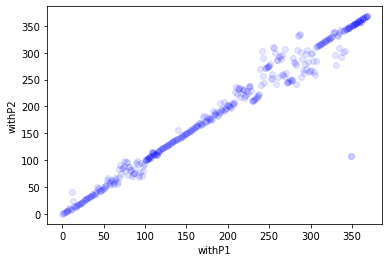

In [148]:
scatter(withP.folds_folditer, withP2.folds_folditer, 'withP1', 'withP2')

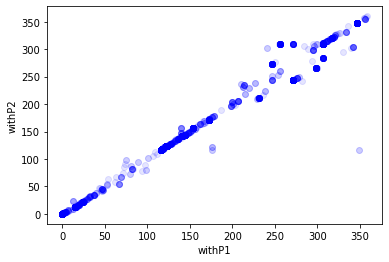

In [149]:
scatter(withP.cpds_folditer, withP2.cpds_folditer, 'withP1', 'withP2')

In [150]:
withP.folds_cumiter['148'], withP.folds_cumiter['3997']

(610, 789)

In [151]:
withP2.folds_cumiter['148'], withP2.folds_cumiter['3997']

(619, 753)

In [152]:
for cumi in range(610, 791):
    print(cumi, {k for k,v in withP.folds_cumiter.items() if v==cumi}, {k for k,v in withP.rns_cumiter.items() if v==cumi})

610 {'148'} set()
611 set() {'R03945_v1'}
612 set() {'R06366', 'R06367', 'R06368'}
613 {'106'} set()
614 {'3896'} {'R01799_v2', 'R01799_v1'}
615 {'7539'} {'R11771', 'R09374_v1'}
616 {'3654'} set()
617 {'270'} {'R00941'}
618 set() {'R07658'}
619 set() {'R07659_v1'}
620 set() {'R07660_v1'}
621 {'3292'} set()
622 {'830'} {'R02828_v1', 'R02828_v2'}
623 {'3117'} {'R02282'}
624 {'1077'} set()
625 {'214'} set()
626 {'4'} set()
627 {'3686'} {'R02826_v2', 'R02826_v1', 'R05596_v1', 'R05379_v1', 'R05596_v2', 'R05379_v2'}
628 set() {'R10535_v1', 'R05780_v1'}
629 {'189'} set()
630 {'7550'} set()
631 set() {'RZ_32', 'R03948', 'R05808'}
632 {'1137'} set()
633 set() {'RZ_28', 'R11580_v1'}
634 set() {'RZ_38', 'R05810', 'R08716', 'R05809', 'RZ_29'}
635 {'4262'} {'R07772'}
636 set() {'RZ_35'}
637 set() {'RZ_30', 'R07773'}
638 set() {'R05812', 'RZ_33', 'RZ_34', 'R05811'}
639 set() {'R07775', 'RZ_37', 'R05813', 'R07774', 'RZ_31', 'CO1_SYN'}
640 set() {'R05814'}
641 set() {'R05218', 'R09599_v1', 'R09598_v1'

In [153]:
for cumi in range(619, 755):
    print(cumi, {k for k,v in withP2.rns_cumiter.items() if v==cumi})

619 set()
620 {'R03945_v1'}
621 {'R06366', 'R06367', 'R06368'}
622 set()
623 {'R03192_v1', 'R03191_v1'}
624 {'R02828_v1', 'R02828_v2'}
625 {'R02184_v1', 'R02184_v2'}
626 set()
627 {'R11341_v1'}
628 {'R11536'}
629 {'R02430'}
630 set()
631 set()
632 set()
633 {'R01567', 'R02099'}
634 set()
635 {'R02282'}
636 {'R00941'}
637 {'R07658'}
638 {'R07659_v1'}
639 {'R07660_v1'}
640 {'R11771', 'R09374_v1'}
641 set()
642 {'R06458_v1', 'R06459_v1'}
643 {'R06461', 'R06460'}
644 {'R01799_v2', 'R01799_v1'}
645 {'R00233'}
646 {'R05373'}
647 {'R12660', 'R06448'}
648 {'R06450', 'R10876'}
649 {'R06483', 'R06482'}
650 {'R06453'}
651 set()
652 {'R01055_v2', 'R01055_v1'}
653 {'R03315', 'R11180_v1'}
654 set()
655 set()
656 {'R02826_v2', 'R02826_v1', 'R05596_v1', 'R05379_v1', 'R05596_v2', 'R05379_v2'}
657 {'R10535_v1', 'R05780_v1'}
658 {'R07376'}
659 {'R04210'}
660 set()
661 {'RZ_314', 'R11583_v1'}
662 {'R02082'}
663 {'R01714_v1'}
664 {'R10597', 'R10666', 'R01302', 'R00986_v1', 'R01715_v1', 'R10583', 'R00985_v1

# withP2

In [154]:
folditer2rnsP2 = {}
for rn, i in withP2.rns_folditer.items():
    if i not in folditer2rnsP2.keys():
        folditer2rnsP2[i] = []
    folditer2rnsP2[i].append(rn)

folditer2foldsP2 = {}
for rn, i in withP2.folds_folditer.items():
    if i not in folditer2foldsP2.keys():
        folditer2foldsP2[i] = []
    folditer2foldsP2[i].append(rn)
    
    

folditer2cpdP2 = {}
for c, order in withP2.cpds_folditer.items():
    if order not in folditer2cpdP2.keys():
        folditer2cpdP2[order] = [c]
    else:
        folditer2cpdP2[order].append(c)
print(len(folditer2cpdP2))
    
folditer2cpdNumP2 = {}
for fold in folditer2cpdP2.keys():
    folditer2cpdNumP2[fold] = len(folditer2cpdP2[fold])

folditer2cpdNumFullP2 = {}
for i in range(0, max(folditer2cpdP2.keys())):
    if i not in folditer2cpdNumP2.keys():
        folditer2cpdNumFullP2[i] = 0
    else:
        folditer2cpdNumFullP2[i] = folditer2cpdNumP2[i]

print(len(folditer2cpdNumFullP2))

170
360


In [155]:
multipleP2 = []
for i, folds in folditer2foldsP2.items():
    if len(folds) > 1:
        multipleP2.append(i)

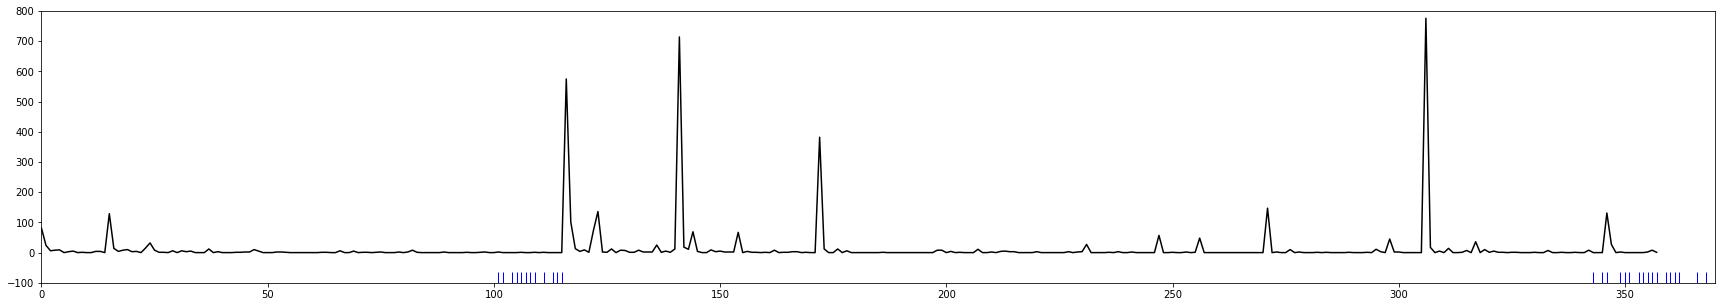

In [156]:
# withP1

plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFullP.values(), color='k')

# sns.rugplot(batm.folds_folditer.values(), height=0.04)
sns.rugplot(multipleP, height=0.04, color='blue')  # double fold injection
# sns.rugplot([368], height=0.08, color='#020079')  # triple fold injection

plt.xlim([0, 370])
plt.ylim([-100, 800])
# plt.savefig('3B_cpds_withP.svg', dpi=300, bbox_inches='tight')
plt.show()

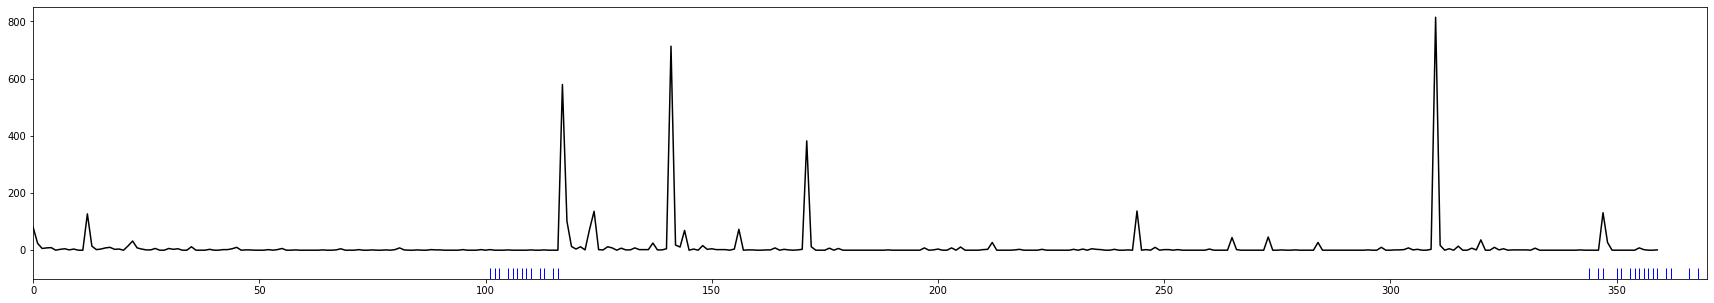

In [157]:
# withP2

plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFullP2.values(), color='k')

# sns.rugplot(batm.folds_folditer.values(), height=0.04)
sns.rugplot(multipleP2, height=0.04, color='blue')  # double fold injection
# sns.rugplot([368], height=0.08, color='#020079')  # triple fold injection

plt.xlim([0, 370])
plt.ylim([-100, 850])
# plt.savefig('3B_cpds_withP.svg', dpi=300, bbox_inches='tight')
plt.show()

In [158]:
group12iter = {}
for x in group1:
    print(f"X{x}: {withP2.folds_folditer[x]} {x2name.get(x, 'no X name')}")
    group12iter[x] = withP2.folds_folditer[x]

X212: 59 no X name
X7501: 141 no X name
X7577: 21 no X name
X206: 31 no X name
X602: 116 L-aspartase middle domain-like
X4953: 117 no X name
X1: 3 cradle loop barrel
X148: 218 Histone-like
X253: 265 no X name
X218: 12 Enolase-N/ribosomal protein
X2492: 92 no X name
X4011: 309 no X name
X327: 169 Alpha-lytic protease prodomain-like
X2005: 95 HUP domain-like
X7579: 39 no X name
X4952: 116 no X name
X2002: 2 TIM beta/alpha-barrel
X330: 133 dsRBD-like
X141: 171 no X name
X297: 47 no X name
X2486: 124 no X name
X3997: 284 no X name
X7523: 71 no X name
X2003: 7 Rossmann-like
X328: 73 IF3-like
X7544: 347 no X name
X304: 11 Alpha-beta plaits
X875: 244 no X name
X109: 17 Repetitive alpha hairpins
X7574: 62 no X name
X3016: 22 no X name
X325: 32 alpha/beta-Hammerhead/Barrel-sandwich hybrid
X2007: 13 Flavodoxin-like
X7584: 310 no X name
X101: 105 HTH
X184: 347 no X name
X2004: 46 P-loop domains-like


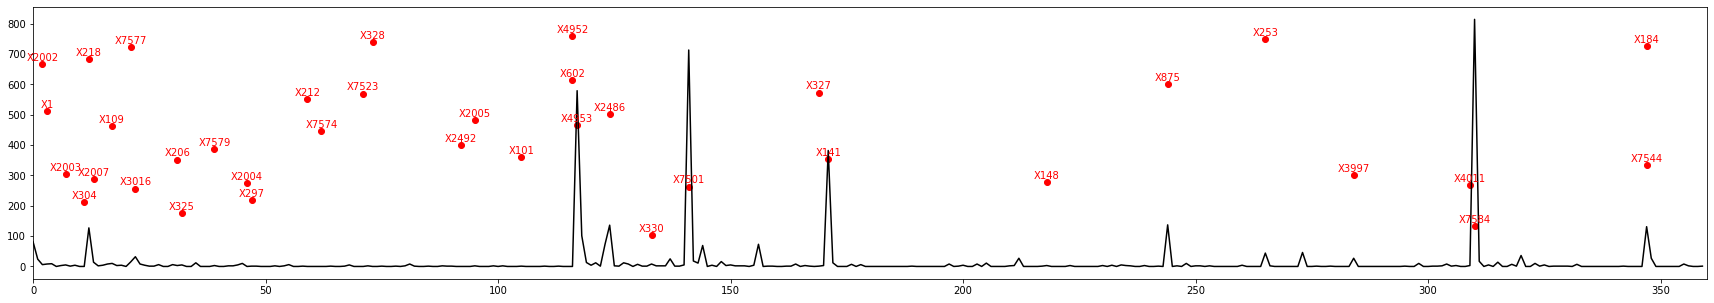

In [159]:
plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFullP2.values(), color='k')

# Add annotations
for key, value in group12iter.items():
    position = random.randint(100, 800)
    plt.text(value, position, 'X'+str(key), ha='center', va='bottom', color='red')
    plt.scatter(value, position-5, color='red')

plt.xlim([0, 360])
# plt.savefig('3B_cpds_group1_withP2.svg', dpi=300, bbox_inches='tight')
plt.show()

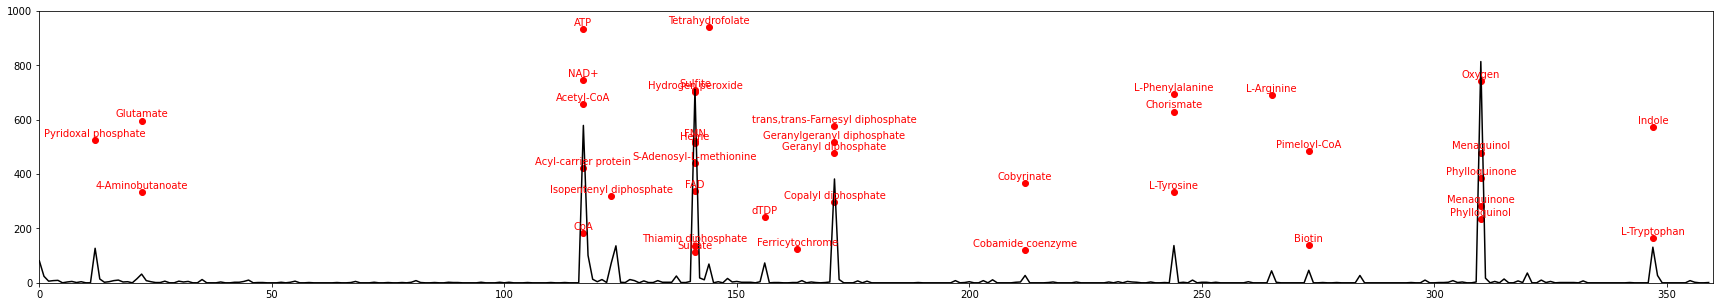

In [160]:
cpd2iterP2 = {}

for cpd in ['C00448', 'C11901', 'C00341', 'C00353', 'C00923', 'C00463', 'C00229', 'C05819', 'C03313', 'C00027', 'C00032', 'C00059', 'C00094', 'C05773', 'C00251', 'C00082', 'C00079', 'C00078', 'C02059', 'C00828', 'C01063', 'C00120', 'C00018', 'C00302', 'C00334', 'C11440', 'C00002', 'C00003', 'C00010', 'C00024', 'C00129', 'C00068', 'C00019', 'C00101', 'C00016', 'C00061', 'C00363', 'C00194', 'C00062', 'C00007']:
    for folditer in folditer2cpdP2.keys():
        for c in folditer2cpdP2[folditer]:
            if c == cpd:
                cpd2iterP2[c] = folditer

plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFullP2.values(), color='k')

# Add annotations
for key, value in cpd2iterP2.items():
    position = random.randint(100, 1000)
    plt.text(value, position, cpd2name[key], ha='center', va='bottom', color='red')
    plt.scatter(value, position-5, color='red')

plt.xlim([0, 360])
plt.ylim([0, 1000])
# plt.savefig('3B_cpds_annotated_withP2.svg', dpi=300, bbox_inches='tight')
plt.show()

In [161]:
withP.folds_folditer['3997'], withP.rns_folditer['R03877'], withP.cpds_folditer['C00007']

(306, 306, 306)

In [162]:
# why did O2 not get made immediately?
withP2.folds_folditer['3997'], withP2.rns_folditer['R03877'], withP2.cpds_folditer['C00007']

(284, 284, 310)

In [163]:
rn2rules['R03877']

{frozenset({'109', '148', '2004', '2007', '3997'})}

In [164]:
for x in ['109', '148', '2004', '2007', '3997']:
    print(x, withP2.folds_folditer[x])

109 17
148 218
2004 46
2007 13
3997 284


In [165]:
withP2.folds_cumiter['3997'], withP2.rns_cumiter['R03877'], withP2.cpds_cumiter['C00007']

(753, 754, 816)

In [166]:
for cumi in range(753, 818):
    print(cumi, {k for k,v in withP2.folds_cumiter.items() if v==cumi}, {k for k,v in withP2.rns_cumiter.items() if v==cumi})

753 {'3997'} set()
754 set() {'RZ_305', 'R03877'}
755 set() {'R11494_v1', 'R11494_v2', 'R04237', 'RZ_308'}
756 set() {'R06269_v1', 'R06268_v1', 'RZ_306', 'R06268_v2', 'R06269_v2'}
757 set() {'RZ_307', 'R06270_v2', 'R11519_v1', 'R06270_v1', 'R06896', 'R06271', 'R06286'}
758 set() {'R03845', 'R06282_v1', 'R11531_v1', 'R06272'}
759 set() {'R08975', 'R06284_v1', 'R09061', 'R09066', 'R09053_v1', 'R06284_v2', 'RZ_485', 'R08585', 'R09033', 'R06288', 'R05618'}
760 set() {'R11507_v2', 'R08584', 'R08914', 'R08915', 'RZ_486', 'R08974', 'R09068', 'R09071_v1', 'R09069', 'R09070', 'R11507_v1', 'R06287', 'R09067_v1', 'R09067_v2', 'R08976'}
761 set() {'R10659', 'R11508_v1', 'R11508_v2'}
762 set() {'R11509_v2', 'R11509_v1'}
763 {'869'} {'R03464'}
764 {'4029'} {'R03947'}
765 {'4049'} {'R02864_v1'}
766 {'4335'} set()
767 {'3001'} {'R04365'}
768 {'3892'} set()
769 {'4295'} {'R01366'}
770 {'7540'} {'R12098'}
771 {'7551'} {'R05789_v1'}
772 {'1114'} set()
773 {'528'} set()
774 set() {'R01886_v1'}
775 {'9'} {

In [167]:
for cumi in range(753, 818):
    print(cumi, {k for k,v in withP2.folds_cumiter.items() if v==cumi}, {k for k,v in withP2.cpds_cumiter.items() if v==cumi})

753 {'3997'} {'C03516'}
754 set() {'C04536'}
755 set() {'C11829', 'C11831'}
756 set() {'C11832', 'C11830', 'C02880'}
757 set() {'C02139', 'C21441'}
758 set() {'C05306', 'C16540', 'C18021', 'C18157', 'C18152'}
759 set() {'Z00058', 'C01389', 'C16541', 'C18063', 'C05307', 'C18151', 'C18064', 'C21427', 'C11850', 'C05797'}
760 set() {'C21428', 'C20764'}
761 set() {'C21429'}
762 set() set()
763 {'869'} set()
764 {'4029'} set()
765 {'4049'} set()
766 {'4335'} set()
767 {'3001'} set()
768 {'3892'} set()
769 {'4295'} set()
770 {'7540'} set()
771 {'7551'} set()
772 {'1114'} set()
773 {'528'} {'C01201'}
774 set() set()
775 {'9'} set()
776 {'1143'} set()
777 {'319'} {'C16218'}
778 set() {'C00412'}
779 set() {'C22177', 'C02041', 'C01530', 'C21394'}
780 set() {'C04088', 'C06425', 'C21393'}
781 set() {'C16221'}
782 set() set()
783 {'525'} set()
784 {'4111'} set()
785 {'154'} {'C01438'}
786 set() set()
787 {'4022'} {'C00785'}
788 set() set()
789 {'4237'} {'C06452'}
790 set() {'C06454'}
791 {'1055'} {'

In [168]:
for rn in {'RZ_473', 'R05394', 'R03816_v1', 'R03816_v2', 'RZ_223'}:
    print(rn, rn2eqn_SI[rn])

R03816_v1 C03313 + C00003 + Z00019 + Z00013 => C02059 + C00004 + C00080 + Z00019 + Z00013
RZ_223 C02059 => Z00022
RZ_473 C02059 => Z00050
R03816_v2 C03313 + C00003 + Z00014 + Z00019 => C02059 + C00004 + C00080 + Z00014 + Z00019
R05394 C06676 => C06675


In [169]:
# for withP2, it's C02059 (Phylloquinone) that ends up producing Oxygen via R09503_vX

for c in ['C06675', 'C02059']:
    print(c, cpd2rn[c])
    for rn in cpd2rn[c]:
        print(f"      {rn} {rn2eqn_SI[rn]}, {rn2reversible[rn]}")

C06675 ['R05278', 'R05394']
      R05278 C06674 + C00007 => C06675, False
      R05394 C06676 => C06675, True
C02059 ['R03511', 'R03816_v1', 'R03816_v2', 'R09503_vX', 'RZ_223', 'RZ_473']
      R03511 C05849 + C00265 => C02059 + C01119 + C00001, False
      R03816_v1 C03313 + C00003 + Z00019 + Z00013 => C02059 + C00004 + C00080 + Z00019 + Z00013, True
      R03816_v2 C03313 + C00003 + Z00014 + Z00019 => C02059 + C00004 + C00080 + Z00014 + Z00019, True
      R09503_vX 2C03313 + C00007 + Z00025 + Z00015 + C04536 + Z00030 + Z00055 => 2C00001 + 2C02059 + 4C00205 + Z00025 + Z00015 + C04536 + Z00030 + Z00055, True
      RZ_223 C02059 => Z00022, False
      RZ_473 C02059 => Z00050, False


### do we get phylloquinol ('C03313') from X7584?

In [170]:
# do we get phylloquinol ('C03313') from X7584?

for rn in cpd2rn['C03313']:
    print(f"{withP2.rns_folditer.get(rn, 'N/A')} {rn} {rn2eqn_SI[rn]}, {rn2reversible[rn]}")

310 R03816_v1 C03313 + C00003 + Z00019 + Z00013 => C02059 + C00004 + C00080 + Z00019 + Z00013, True
310 R03816_v2 C03313 + C00003 + Z00014 + Z00019 => C02059 + C00004 + C00080 + Z00014 + Z00019, True
310 R04994 C03313 + C00021 => C21084 + C00019, True
N/A R05144 C06247 + C03313 + C00011 + C00007 => C06246 + C05849 + C00001, False
310 R09503_vX 2C03313 + C00007 + Z00025 + Z00015 + C04536 + Z00030 + Z00055 => 2C00001 + 2C02059 + 4C00205 + Z00025 + Z00015 + C04536 + Z00030 + Z00055, True
310 RZ_225 C03313 => Z00022, False
310 RZ_474 C03313 => Z00050, False


In [171]:
for rn in ['R03816_v1', 'R03816_v2', 'R04994']:
    print(withP2.rns_folditer[rn], rn, rn2rules[rn])
    print(rn2eqn_SI[rn], rn2reversible[rn])
    
    r, p = rn2eqn_SI[rn].split(' => ')[0].split(' + '), rn2eqn_SI[rn].split(' => ')[1].split(' + ')
    print('L------------')
    for c in r:
        print(withP2.cpds_folditer[c[-6:]], c[-6:], zcpd2name[c[-6:]])
    print('R------------')
    for c in p:
        print(withP2.cpds_folditer[c[-6:]], c[-6:], zcpd2name[c[-6:]])
    print('')

310 R03816_v1 {frozenset({'2007'}), frozenset({'2003'})}
C03313 + C00003 + Z00019 + Z00013 => C02059 + C00004 + C00080 + Z00019 + Z00013 True
L------------
310 C03313 Phylloquinol
117 C00003 NAD+
141 Z00019 Flavoprotein
141 Z00013 FAD
R------------
310 C02059 Phylloquinone
117 C00004 NADH
0 C00080 H+
141 Z00019 Flavoprotein
141 Z00013 FAD

310 R03816_v2 {frozenset({'2007'}), frozenset({'2003'})}
C03313 + C00003 + Z00014 + Z00019 => C02059 + C00004 + C00080 + Z00014 + Z00019 True
L------------
310 C03313 Phylloquinol
117 C00003 NAD+
141 Z00014 FMN
141 Z00019 Flavoprotein
R------------
310 C02059 Phylloquinone
117 C00004 NADH
0 C00080 H+
141 Z00014 FMN
141 Z00019 Flavoprotein

310 R04994 {frozenset({'2003'})}
C03313 + C00021 => C21084 + C00019 True
L------------
310 C03313 Phylloquinol
117 C00021 S-Adenosyl-L-homocysteine
R------------
310 C21084 Demethylphylloquinol
141 C00019 S-Adenosyl-L-methionine



In [172]:
# C21084 Demethylphylloquinol

for rn in cpd2rn['C21084']:
    print(f"{withP2.rns_folditer.get(rn, 'N/A')} {rn} {rn2eqn_SI[rn]}, {rn2reversible[rn]}")

310 R04994 C03313 + C00021 => C21084 + C00019, True
310 R11061_v1 C21084 + C00006 + Z00021 => C13309 + C00005 + C00080 + Z00021, True
310 R11061_v2 C21084 + C00006 + Z00013 => C13309 + C00005 + C00080 + Z00013, True


In [173]:
for rn in cpd2rn['C21084']:
    print(withP2.rns_folditer[rn], rn, rn2rules[rn])
    print(rn2eqn_SI[rn], rn2reversible[rn])
    
    r, p = rn2eqn_SI[rn].split(' => ')[0].split(' + '), rn2eqn_SI[rn].split(' => ')[1].split(' + ')
    print('L------------')
    for c in r:
        print(withP2.cpds_folditer[c[-6:]], c[-6:], zcpd2name[c[-6:]])
    print('R------------')
    for c in p:
        print(withP2.cpds_folditer[c[-6:]], c[-6:], zcpd2name[c[-6:]])
    print('')

310 R04994 {frozenset({'2003'})}
C03313 + C00021 => C21084 + C00019 True
L------------
310 C03313 Phylloquinol
117 C00021 S-Adenosyl-L-homocysteine
R------------
310 C21084 Demethylphylloquinol
141 C00019 S-Adenosyl-L-methionine

310 R11061_v1 {frozenset({'2003'})}
C21084 + C00006 + Z00021 => C13309 + C00005 + C00080 + Z00021 True
L------------
310 C21084 Demethylphylloquinol
117 C00006 NADP+
141 Z00021 Generic Flavin
R------------
310 C13309 2-Phytyl-1,4-naphthoquinone
117 C00005 NADPH
0 C00080 H+
141 Z00021 Generic Flavin

310 R11061_v2 {frozenset({'2003'})}
C21084 + C00006 + Z00013 => C13309 + C00005 + C00080 + Z00013 True
L------------
310 C21084 Demethylphylloquinol
117 C00006 NADP+
141 Z00013 FAD
R------------
310 C13309 2-Phytyl-1,4-naphthoquinone
117 C00005 NADPH
0 C00080 H+
141 Z00013 FAD



In [174]:
# C13309 2-Phytyl-1,4-naphthoquinone

for rn in cpd2rn['C13309']:
    print(f"{withP2.rns_folditer.get(rn, 'N/A')} {rn} {rn2eqn_SI[rn]}, {rn2reversible[rn]}")

310 R11061_v1 C21084 + C00006 + Z00021 => C13309 + C00005 + C00080 + Z00021, True
310 R11061_v2 C21084 + C00006 + Z00013 => C13309 + C00005 + C00080 + Z00013, True
310 R12255 C13309 + C00013 + C00011 => C05427 + C22039, True
310 RZ_196 C13309 => Z00022, False


In [175]:
for rn in cpd2rn['C13309']:
    print(withP2.rns_folditer[rn], rn, rn2rules[rn])
    print(rn2eqn_SI[rn], rn2reversible[rn])
    
    r, p = rn2eqn_SI[rn].split(' => ')[0].split(' + '), rn2eqn_SI[rn].split(' => ')[1].split(' + ')
    print('L------------')
    for c in r:
        print(withP2.cpds_folditer[c[-6:]], c[-6:], zcpd2name[c[-6:]])
    print('R------------')
    for c in p:
        print(withP2.cpds_folditer[c[-6:]], c[-6:], zcpd2name[c[-6:]])
    print('')

310 R11061_v1 {frozenset({'2003'})}
C21084 + C00006 + Z00021 => C13309 + C00005 + C00080 + Z00021 True
L------------
310 C21084 Demethylphylloquinol
117 C00006 NADP+
141 Z00021 Generic Flavin
R------------
310 C13309 2-Phytyl-1,4-naphthoquinone
117 C00005 NADPH
0 C00080 H+
141 Z00021 Generic Flavin

310 R11061_v2 {frozenset({'2003'})}
C21084 + C00006 + Z00013 => C13309 + C00005 + C00080 + Z00013 True
L------------
310 C21084 Demethylphylloquinol
117 C00006 NADP+
141 Z00013 FAD
R------------
310 C13309 2-Phytyl-1,4-naphthoquinone
117 C00005 NADPH
0 C00080 H+
141 Z00013 FAD

310 R12255 {frozenset({'141'})}
C13309 + C00013 + C00011 => C05427 + C22039 True
L------------
310 C13309 2-Phytyl-1,4-naphthoquinone
2 C00013 Diphosphate
0 C00011 CO2
R------------
171 C05427 Phytyl diphosphate
310 C22039 2-Carboxy-1,4-naphthoquinone



KeyError: 'RZ_196'

In [ ]:
# C22039 2-Carboxy-1,4-naphthoquinone

for rn in cpd2rn['C22039']:
    print(f"{withP2.rns_folditer.get(rn, 'N/A')} {rn} {rn2eqn_SI[rn]}, {rn2reversible[rn]}")

In [ ]:
for rn in cpd2rn['C22039']:
    print(withP2.rns_folditer[rn], rn, rn2rules.get(rn, 'not in rn2rules'))
    print(rn2eqn_SI[rn], rn2reversible[rn])
    
    r, p = rn2eqn_SI[rn].split(' => ')[0].split(' + '), rn2eqn_SI[rn].split(' => ')[1].split(' + ')
    print('L------------')
    for c in r:
        print(withP2.cpds_folditer[c[-6:]], c[-6:], zcpd2name[c[-6:]])
    print('R------------')
    for c in p:
        print(withP2.cpds_folditer[c[-6:]], c[-6:], zcpd2name[c[-6:]])
    print('')

In [ ]:
# C03657 1,4-Dihydroxy-2-naphthoate
c = 'C03657'

for rn in cpd2rn[c]:
    print(f"{withP2.rns_folditer.get(rn, 'N/A')} {rn} {rn2eqn_SI[rn]}, {rn2reversible[rn]}")
print('========================')
print('')

for rn in cpd2rn[c]:
    print(withP2.rns_folditer[rn], rn, rn2rules.get(rn, 'not in rn2rules'))
    print(rn2eqn_SI[rn], rn2reversible[rn])
    
    r, p = rn2eqn_SI[rn].split(' => ')[0].split(' + '), rn2eqn_SI[rn].split(' => ')[1].split(' + ')
    print('L------------')
    for c in r:
        print(withP2.cpds_folditer[c[-6:]], c[-6:], zcpd2name[c[-6:]])
    print('R------------')
    for c in p:
        print(withP2.cpds_folditer[c[-6:]], c[-6:], zcpd2name[c[-6:]])
    print('')

### try from X875...

In [ ]:
x2rn_required['875']

In [ ]:
rn = 'R01714_v1'
print(f"{withP2.rns_folditer.get(rn, 'N/A')} {rn} {rn2eqn_SI[rn]}, {rn2reversible[rn]}")
print('========================')
print('')

print(withP2.rns_folditer[rn], rn, rn2rules.get(rn, 'not in rn2rules'))
print(rn2eqn_SI[rn], rn2reversible[rn])

r, p = rn2eqn_SI[rn].split(' => ')[0].split(' + '), rn2eqn_SI[rn].split(' => ')[1].split(' + ')
print('L------------')
for c in r:
    print(withP2.cpds_folditer[c[-6:]], c[-6:], zcpd2name[c[-6:]])
print('R------------')
for c in p:
    print(withP2.cpds_folditer[c[-6:]], c[-6:], zcpd2name[c[-6:]])
print('')

### chorismate & phylloquinone must be connected 

In [ ]:
# see KEGG map https://www.genome.jp/pathway/map00130+C00251

In [ ]:
"""
'R01714_v1': '875'

'4011', '7584'
"""

# 5-O-(1-Carboxyvinyl)-3-phosphoshikimate (C01269)
# Chorismate (C00251)

In [ ]:
batm.folds_folditer['875'], batm.folds_folditer['4011'], batm.folds_folditer['7584']

In [ ]:
batm.cpds_folditer['C00251'], batm.cpds_folditer['C03313'], batm.cpds_folditer['C02059'], batm.cpds_folditer['C02191']

# how to get from chlorophyll to O2

In [ ]:
for rn in cpd2rn['C03516']:
    print('============================')
    print(withP2.rns_folditer[rn], rn, rn2eqn_SI[rn], rn2reversible[rn])
    
    r, p = rn2eqn_SI[rn].split(' => ')[0].split(' + '), rn2eqn_SI[rn].split(' => ')[1].split(' + ')
    print('L------------')
    for c in r:
        print(withP2.cpds_folditer[c[-6:]], c[-6:], zcpd2name[c[-6:]])
    print('R------------')
    for c in p:
        print(c[-6:], zcpd2name[c[-6:]])
    

In [ ]:
for rn in cpd2rn['C04536']:
    print(withP2.rns_folditer[rn], rn, rn2eqn_SI[rn], rn2reversible[rn])
    
    r, p = rn2eqn_SI[rn].split(' => ')[0].split(' + '), rn2eqn_SI[rn].split(' => ')[1].split(' + ')
    print('L------------')
    for c in r:
        print(withP2.cpds_folditer[c[-6:]], c[-6:], zcpd2name[c[-6:]])
    print('R------------')
    for c in p:
        print(withP2.cpds_folditer[c[-6:]], c[-6:], zcpd2name[c[-6:]])
    print('')
    print('')

In [ ]:
# O2 production from chlorophyll is gated by phylloquinol / phylloquinone...

In [ ]:
withP.cpds_folditer["C03313"], withP.cpds_folditer["C02059"]

In [ ]:
withP2.cpds_folditer["C03313"], withP2.cpds_folditer["C02059"]

In [ ]:
folditer2foldsP2[310]

In [ ]:
for rn in x2rn_required['7584']:
    print(rn, rn2eqn_SI.get(rn, ''), rn2reversible.get(rn, ''))
    if rn2eqn_SI.get(rn, '') != '':
        r, p = rn2eqn_SI[rn].split(' => ')[0].split(' + '), rn2eqn_SI[rn].split(' => ')[1].split(' + ')
        print('L------------')
        for c in r:
            print([batm.cpds_folditer.get(c[-6:], 'not found'), withP2.cpds_folditer.get(c[-6:], 'not found')], c[-6:], zcpd2name[c[-6:]])
        print('R------------')
        for c in p:
            print([batm.cpds_folditer.get(c[-6:], 'not found'), withP2.cpds_folditer.get(c[-6:], 'not found')], c[-6:], zcpd2name[c[-6:]])
        print('')
        print('')

In [ ]:
for rn in x2rn['148']:
    print(withP2.rns_folditer.get(rn, 'rn not found'), rn, rn2eqn_SI.get(rn, ''))
    if rn2eqn_SI.get(rn, '') != '':
        r, p = rn2eqn_SI[rn].split(' => ')[0].split(' + '), rn2eqn_SI[rn].split(' => ')[1].split(' + ')
        print('L------------')
        for c in r:
            print([batm.cpds_folditer.get(c[-6:], 'not found'), withP2.cpds_folditer.get(c[-6:], 'not found')], c[-6:], zcpd2name[c[-6:]])
        print('R------------')
        for c in p:
            print([batm.cpds_folditer.get(c[-6:], 'not found'), withP2.cpds_folditer.get(c[-6:], 'not found')], c[-6:], zcpd2name[c[-6:]])
        print('')
    else:
        print('')
        

In [ ]:
# required rn

for rn in x2rn_required['148']:
    print(withP2.rns_folditer.get(rn, 'rn not found'), rn, rn2eqn_SI.get(rn, ''))
    if rn2eqn_SI.get(rn, '') != '':
        r, p = rn2eqn_SI[rn].split(' => ')[0].split(' + '), rn2eqn_SI[rn].split(' => ')[1].split(' + ')
        print('L------------')
        for c in r:
            print([batm.cpds_folditer[c[-6:]], withP2.cpds_folditer[c[-6:]]], c[-6:], zcpd2name[c[-6:]])
        print('R------------')
        for c in p:
            print([batm.cpds_folditer[c[-6:]], withP2.cpds_folditer[c[-6:]]], c[-6:], zcpd2name[c[-6:]])
        print('')
    else:
        print('')
        

# protein ablation!

In [ ]:
NoP = pd.read_pickle('../runs/2024-04-24_12-36-40_protein_ablation.pkl.gz')

In [ ]:
folditer2rnsNoP = {}
for rn, i in NoP.rns_folditer.items():
    if i not in folditer2rnsNoP.keys():
        folditer2rnsNoP[i] = []
    folditer2rnsNoP[i].append(rn)

folditer2foldsNoP = {}
for rn, i in NoP.folds_folditer.items():
    if i not in folditer2foldsNoP.keys():
        folditer2foldsNoP[i] = []
    folditer2foldsNoP[i].append(rn)
    
    

folditer2cpdNoP = {}
for c, order in NoP.cpds_folditer.items():
    if order not in folditer2cpdNoP.keys():
        folditer2cpdNoP[order] = [c]
    else:
        folditer2cpdNoP[order].append(c)
print(len(folditer2cpdNoP))
    
folditer2cpdNumNoP = {}
for fold in folditer2cpdNoP.keys():
    folditer2cpdNumNoP[fold] = len(folditer2cpdNoP[fold])

folditer2cpdNumFullNoP = {}
for i in range(0, max(folditer2cpdNoP.keys())):
    if i not in folditer2cpdNumNoP.keys():
        folditer2cpdNumFullNoP[i] = 0
    else:
        folditer2cpdNumFullNoP[i] = folditer2cpdNumNoP[i]

print(len(folditer2cpdNumFullNoP))

In [ ]:
multipleNoP = []
for i, folds in folditer2foldsNoP.items():
    if len(folds) > 1:
        multipleNoP.append(i)

In [ ]:
folditer2foldsNoP

In [ ]:
# with P

plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFullNoP.values(), color='k')

# sns.rugplot(batm.folds_folditer.values(), height=0.04)
sns.rugplot(multipleNoP, height=0.04, color='blue')  # double fold injection
sns.rugplot([303], height=0.08, color='#020079')  # triple fold injection

plt.xlim([0, 370])
plt.ylim([-100, 800])
# plt.savefig('3B_cpds_withP.svg', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
len(NoP.scope.folds), len(NoP.scope.cpds)

In [ ]:
'C00007' in NoP.scope.cpds  # no Oxygen!!

In [ ]:
'C02059' in NoP.scope.cpds  # no Phylloquinone!!

In [ ]:
group12iterNoP = {}
for x in group1:
#     print(f"X{x}: {NoP.folds_folditer[x]} {x2name.get(x, 'no X name')}")
    group12iterNoP[x] = NoP.folds_folditer[x]

In [ ]:
plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFullNoP.values(), color='k')

# Add annotations
for key, value in group12iterNoP.items():
    position = random.randint(100, 800)
    plt.text(value, position, 'X'+str(key), ha='center', va='bottom', color='green')
    plt.scatter(value, position-5, color='green')

plt.xlim([0, 360])
# plt.savefig('3B_cpds_group1_withP.svg', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
cpd2iterNoP = {}

for cpd in ['C00448', 'C11901', 'C00341', 'C00353', 'C00923', 'C00463', 'C00229', 'C05819', 'C03313', 'C00027', 'C00032', 'C00059', 'C00094', 'C05773', 'C00251', 'C00082', 'C00079', 'C00078', 'C02059', 'C00828', 'C01063', 'C00120', 'C00018', 'C00302', 'C00334', 'C11440', 'C00002', 'C00003', 'C00010', 'C00024', 'C00129', 'C00068', 'C00019', 'C00101', 'C00016', 'C00061', 'C00363', 'C00194', 'C00062', 'C00007']:
    for folditer in folditer2cpdNoP.keys():
        for c in folditer2cpdNoP[folditer]:
            if c == cpd:
                cpd2iterNoP[c] = folditer

plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFullNoP.values(), color='k')

# Add annotations
for key, value in cpd2iterNoP.items():
    position = random.randint(100, 1000)
    plt.text(value, position, cpd2name[key], ha='center', va='bottom', color='green')
    plt.scatter(value, position-5, color='green')

plt.xlim([0, 360])
plt.ylim([0, 1000])
# plt.savefig('3B_cpds_annotated_withNoP.svg', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
for rn in x2rn_required['148']:
    print(batm.rns_folditer.get(rn, 'N/A'), rn, rn2eqn_SI.get(rn, ''))

In [ ]:
"""
# protein (C00017) => Flavoprotein (Z00019) =={'R03816_v1': '2003' or '2007'}==> phylloquinone (C02059)

# C02191 Protoporphyrin =={'R03877': {'109', '148', '2004', '2007', '3997'}}==> C03516 Magnesium protoporphyrin
# C03516 Magnesium protoporphyrin =={'R04237': '2003'}==> C04536 Magnesium protoporphyrin monomethyl ester

# Mg protoporphyrin monomethyl ester (C04536) + phylloquinone (C02059) =={'R09503_vX': ?}==> Oxygen (C00007)
"""

In [ ]:
# protein (C00017) => Flavoprotein (Z00019)
# Flavoprotein (Z00019) + Phylloquinol (C03313) =={'R03816_v1': '2003' or '2007'}==> phylloquinone (C02059)

# Protoporphyrin (C02191) =={'R03877': {'109', '148', '2004', '2007', '3997'}}==> Magnesium protoporphyrin (C03516)
# Magnesium protoporphyrin (C03516) =={'R04237': '2003'}==> Magnesium protoporphyrin monomethyl ester (C04536)

# Mg protoporphyrin monomethyl ester (C04536) + phylloquinone (C02059) =={'R09503_vX': ?}==> Oxygen (C00007)

In [ ]:
for rn, eqn in rn2eqn_SI.items():
    if 'Z00019' in eqn:
        print(batm.rns_folditer.get(rn, 'N/A'), rn, eqn)

In [ ]:
for c in ['C04570', 'C04253', 'C03161', 'C03024']:
    print(c, cpd2name[c])

In [ ]:
c = 'C02059'
for rn in cpd2rn[c]:
    print(f"{batm.rns_folditer.get(rn, 'N/A')} {rn} {rn2eqn_SI[rn]}, {rn2reversible[rn]}")

In [ ]:
zcpd2name['C03313']

In [ ]:
zcpd2name['Z00019']

In [ ]:
'Z00019' in NoP.scope.cpds  # no Flavoprotein!

In [ ]:
'C02191' in NoP.scope.cpds  

In [ ]:
c = 'C03313'
for rn in cpd2rn[c]:
    print(f"{batm.rns_folditer.get(rn, 'N/A')} {rn} {rn2eqn_SI[rn]}, {rn2reversible[rn]}")

In [ ]:
rn2rules['R04994']

In [ ]:
r, p = rn2eqn_SI['R09503_vX'].split(' => ')[0].split(' + '), rn2eqn_SI['R09503_vX'].split(' => ')[1].split(' + ')
print('L------------')
for c in r:
    print(batm.cpds_folditer[c[-6:]], c[-6:], zcpd2name[c[-6:]])
print('R------------')
for c in p:
    print(batm.cpds_folditer[c[-6:]], c[-6:], zcpd2name[c[-6:]])

In [ ]:
for rn in cpd2rn['C02191']:
    print(batm.rns_folditer[rn], rn, rn2eqn_SI[rn], rn2reversible[rn])

In [ ]:
cpd2name['C01079']

# 5 runs of withP

In [ ]:
withP3 = pd.read_pickle('../runs/2024-04-25_10-36-05_with_protein3.pkl.gz')
withP4 = pd.read_pickle('../runs/2024-04-25_19-05-23_with_protein4.pkl.gz')
withP5 = pd.read_pickle('../runs/2024-04-25_20-12-46_with_protein5.pkl.gz')

In [ ]:
print(withP.cpds_folditer['C00007'], withP2.cpds_folditer['C00007']) 
print(withP3.cpds_folditer['C00007'], withP4.cpds_folditer['C00007'], withP5.cpds_folditer['C00007'])

In [ ]:
print(withP.cpds_folditer['C00251'], withP2.cpds_folditer['C00251']) 
print(withP3.cpds_folditer['C00251'], withP4.cpds_folditer['C00251'], withP5.cpds_folditer['C00251'])

# withP + ATP pre-expansion

In [ ]:
preATP = pd.read_pickle('../runs/2024-04-25_18-10-30_withP_preATP.pkl.gz')

In [ ]:
folditer2rnsATP = {}
for rn, i in preATP.rns_folditer.items():
    if i not in folditer2rnsATP.keys():
        folditer2rnsATP[i] = []
    folditer2rnsATP[i].append(rn)

folditer2foldsATP = {}
for rn, i in preATP.folds_folditer.items():
    if i not in folditer2foldsATP.keys():
        folditer2foldsATP[i] = []
    folditer2foldsATP[i].append(rn)
    
    

folditer2cpdATP = {}
for c, order in preATP.cpds_folditer.items():
    if order not in folditer2cpdATP.keys():
        folditer2cpdATP[order] = [c]
    else:
        folditer2cpdATP[order].append(c)
print(len(folditer2cpdATP))
    
folditer2cpdNumATP = {}
for fold in folditer2cpdATP.keys():
    folditer2cpdNumATP[fold] = len(folditer2cpdATP[fold])

folditer2cpdNumFullATP = {}
for i in range(0, max(folditer2cpdATP.keys())):
    if i not in folditer2cpdNumATP.keys():
        folditer2cpdNumFullATP[i] = 0
    else:
        folditer2cpdNumFullATP[i] = folditer2cpdNumATP[i]

print(len(folditer2cpdNumFullATP))

In [ ]:
multipleATP = []
for i, folds in folditer2foldsATP.items():
    if len(folds) > 1:
        multipleATP.append(i)

In [ ]:
len(multipleATP)

In [ ]:
folditer2foldsATP

In [ ]:
plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFullATP.values(), color='k')

sns.rugplot(multipleATP, height=0.04, color='blue')  # double fold injection
sns.rugplot([374], height=0.08, color='#020079')  # triple fold injection

plt.xlim([0, 375])
plt.ylim([-100, 900])
# plt.savefig('3B_cpds.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
group12iterATP = {}
for x in group1:
    print(f"X{x}: {preATP.folds_folditer[x]} {x2name.get(x, 'no X name')}")
    group12iterATP[x] = preATP.folds_folditer[x]

In [ ]:
plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFullATP.values(), color='k')

# Add annotations
for key, value in group12iterATP.items():
    position = random.randint(100, 800)
    plt.text(value, position, 'X'+str(key), ha='center', va='bottom', color='gray')
    plt.scatter(value, position-5, color='gray')

plt.xlim([0, 360])
# plt.savefig('3B_cpds_group1_withP.svg', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
cpd2iterATP = {}

for cpd in ['C00448', 'C11901', 'C00341', 'C00353', 'C00923', 'C00463', 'C00229', 'C05819', 'C03313', 'C00027', 'C00032', 'C00059', 'C00094', 'C05773', 'C00251', 'C00082', 'C00079', 'C00078', 'C02059', 'C00828', 'C01063', 'C00120', 'C00018', 'C00302', 'C00334', 'C11440', 'C00002', 'C00003', 'C00010', 'C00024', 'C00129', 'C00068', 'C00019', 'C00101', 'C00016', 'C00061', 'C00363', 'C00194', 'C00062', 'C00007']:
    for folditer in folditer2cpdATP.keys():
        for c in folditer2cpdATP[folditer]:
            if c == cpd:
                cpd2iterATP[c] = folditer

plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFullATP.values(), color='k')

# Add annotations
for key, value in cpd2iterATP.items():
    position = random.randint(100, 1000)
    plt.text(value, position, cpd2name[key], ha='center', va='bottom', color='grey')
    plt.scatter(value, position-5, color='grey')

plt.xlim([0, 360])
plt.ylim([0, 1000])
# plt.savefig('3B_cpds_annotated_withP_preATP.svg', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# L-arginine 
preATP.cpds_folditer['C00062']

In [ ]:
# which L-arginine rn are gated by X602/X4953 or X4952?
# which rn produces L-arginine?

for rn in cpd2rn['C00062']:
    print(preATP.rns_folditer.get(rn, 'N/A'), rn, rn2rules.get(rn, 'not in rn2rules'))

In [ ]:
# 'R01086' is Arg synthesis, requires X602/X4953
rn2eqn_SI['R01086'], rn2reversible['R01086']

In [ ]:
cpd2name['C03406']

In [ ]:
# arginosuccinate
preATP.cpds_folditer['C03406']